# TT2 — Energy histogram threshold

Estimate each recording's energy threshold from the first two histogram peaks. Show the TRAIN candidate-frame F1 proposal separately from global FINAL W calibration on the four TRAIN recordings.

This notebook contains all computation for one student's algorithm. Run the cells in order with Python 3, matplotlib and IPython. WAV/LAB input is supplied separately in `data/train/` and `data/test/`; edit `DATA_DIR` if needed. The notebook discovers these folders from its working directory and ancestors.

The signal is framed with full 25 ms windows and 10 ms hops, using Python's nearest-sample rounding with ties to even. Energy is STE divided by frame size. Default MODE=enhanced requires HIGH confirmation and continuation above LOW. Core uses native decisions without HIGH/LOW, final padding or duration filtering. The 200 ms rule measures estimated gaps between active frame supports; exact 200 ms is preserved. Enhanced alone uses the 100 ms support-span heuristic. Overlapping frames can bridge physical silence or retain brief impulses; these settings do not guarantee 200 ms of physical silence or 100 ms of voiced audio. Training and test results are labeled separately. Every number and plot below is recomputed from input WAV/LAB; no saved model or result is loaded.

For standalone use, choose **Restart Kernel and Run All** and save the executed notebook so tables and plots stay visible; this notebook needs no project modules or generator/runner scripts to execute. Submit this `.ipynb` without bundling WAV or other signal files.

Project maintainers refresh this repository's audited CODE ZIP by rebuilding with `tools/build_notebooks.py`, executing with `tools/run_notebooks.py` in fresh kernels, then checking saved evidence with `--validate-only`. That runner hashes ordered code-cell sources after removing its temporary audit cell. A code edit, including a comment, requires fresh runner execution before the repository's source-bound audit/packaging accepts it; this audit requirement is separate from standalone notebook execution.


## Imports and fixed configuration

Only the standard library, matplotlib and IPython are used. Timing and endpoint rules are fixed.


In [1]:
import math
import wave
import hashlib
import json
import html
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, display

ALGORITHM = 'tt2'
MODE = "enhanced"  # selected mode for the four plots and illustration
FRAME_MS = 25.0
HOP_MS = 10.0
SAMPLE_ROUNDING = "nearest_integer_samples_python_round_ties_to_even"
MIN_SILENCE_SECONDS = 0.200
MIN_SPEECH_SECONDS = 0.100
BOUNDARY_TOLERANCE_SECONDS = 0.100
HISTOGRAM_W_TIE_PREFERENCE = 20.0
PADDING_MS = 250.0
PADDING_FRAMES = round(PADDING_MS / HOP_MS)
FILE_ORDER = ("phone_F2", "phone_M2", "studio_F2", "studio_M2")

# Optional: edit this to the folder containing train/ and test/.
# None discovers data/ from the working directory and its ancestors.
DATA_DIR = None
plt.rcParams.update({"figure.dpi": 115, "font.size": 10})


## WAV and LAB input

PCM decoding and interval validation are manual. `sil=0`; `v` and `uv` are speech. Optional Praat metadata lines are ignored after format validation.


In [2]:
def read_wav(path):
    """Đọc WAV PCM nguyên và chuyển các kênh thành waveform mono.

    Đầu vào: path là đường dẫn WAV PCM 8/16/24/32 bit không nén.
    Đầu ra: Tuple (samples, fs): list float chia toàn thang PCM và tần số mẫu Hz từ header.

    Các mẫu trả về được chia cho toàn thang PCM, không chuẩn hóa theo đỉnh.
    Với PCM 8 bit, dữ liệu không dấu được dịch về tâm 0 trước khi chia.
    Tần số mẫu lấy trực tiếp từ header; WAV nén bị từ chối rõ ràng.
    """
    # Header xác định Fs, số kênh và số byte mỗi mẫu.
    # Chỉ nhận PCM nguyên không nén để giải mã từng byte rõ ràng.
    # PCM 8 bit không dấu được dịch về tâm 0; các độ rộng khác có dấu.
    # Chia toàn thang PCM rồi lấy trung bình các kênh tại cùng thời điểm.
    # Không chuẩn hóa theo đỉnh waveform; STE được chuẩn hóa ở features.
    with wave.open(str(path), "rb") as source:
        channels, width = source.getnchannels(), source.getsampwidth()
        fs = source.getframerate()
        if source.getcomptype() != "NONE" or width not in (1, 2, 3, 4):
            raise ValueError(f"WAV cần PCM nguyên 8/16/24/32 bit: {path}")
        raw = source.readframes(source.getnframes())
    samples = []
    scale = float(1 << (width * 8 - 1))
    # Một frame WAV chứa lần lượt một mẫu của mỗi kênh.
    # Chuyển PCM sang float trước khi trộn để giữ toàn thang [-1, 1).
    for offset in range(0, len(raw), width * channels):
        total = 0.0
        for channel in range(channels):
            index = offset + channel * width
            block = raw[index:index + width]
            value = block[0] - 128 if width == 1 else int.from_bytes(block, "little", signed=True)
            total += value / scale
        samples.append(total / channels)
    return samples, fs


def read_lab(path, duration):
    """Đọc, kiểm tra và chặn các khoảng nhãn theo thời lượng WAV.

    Đầu vào: path là đường dẫn LAB; duration là thời lượng WAV dương, hữu hạn theo giây.
    Đầu ra: List (start, end, label) theo giây với label sil/v/uv; lỗi ghi rõ dòng nguồn.

    Nhãn hợp lệ là sil, v, uv; lỗi dữ liệu báo kèm số dòng, không bị nuốt.
    Kiểm tra thứ tự và đoạn chồng lấn trước khi chặn biên theo WAV.
    Sai lệch cuối tối đa 10 ms được chấp nhận do LAB làm tròn 2 chữ số.
    Khoảng âm thanh ngoài nhãn không tự được gán thành khoảng lặng.
    """
    # Thời lượng WAV phải hợp lệ trước khi kiểm tra nhãn.
    # Bỏ dòng trắng và chỉ hai dạng thống kê F0 được quy định.
    # Mỗi đoạn phải có đủ start/end/nhãn và thứ tự không chồng lấn.
    # LAB có thể làm tròn đuôi trong 10 ms, sau đó chặn END theo WAV.
    # Khoảng không được LAB phủ vẫn thiếu nhãn, không tự thêm silence.
    if not math.isfinite(duration) or duration <= 0:
        raise ValueError("Thời lượng WAV phải dương và hữu hạn")
    path = Path(path)
    intervals, previous_end = [], 0.0
    # Không suy luận nhãn từ dòng lỗi: mỗi lỗi phải được phát hiện tại nguồn.
    with path.open(encoding="utf-8-sig") as source:
        for number, line in enumerate(source, 1):
            columns = line.split()
            if not columns:
                continue
            error = f"{path.name}, dòng {number}: LAB không hợp lệ"
            if columns[0] in ("F0mean", "F0std"):
                # Hai dòng F0 là thống kê Praat; kiểm tra định dạng rồi bỏ qua.
                if len(columns) != 2:
                    raise ValueError(error)
                try:
                    value = float(columns[1])
                except ValueError as exc:
                    raise ValueError(error) from exc
                if not math.isfinite(value) or value < 0:
                    raise ValueError(error)
                continue
            if len(columns) != 3 or columns[2] not in ("sil", "v", "uv"):
                raise ValueError(error)
            try:
                start, end = float(columns[0]), float(columns[1])
            except ValueError as exc:
                raise ValueError(error) from exc
            # Kiểm tra số, thứ tự và thời lượng trước khi chặn sai lệch làm tròn.
            if (not math.isfinite(start) or not math.isfinite(end)
                    or start < 0 or end <= start or start < previous_end - 1e-9
                    or end > duration + 0.010001):
                raise ValueError(error)
            previous_end = end
            end = min(end, duration)
            if start < end:
                intervals.append((start, end, columns[2]))
    if not intervals:
        raise ValueError(f"{path.name}: không có đoạn nhãn")
    return intervals


In [3]:
def find_data_root(data_dir=None):
    """Resolve a dataset supplied separately from this notebook."""
    if data_dir is not None:
        requested = Path(data_dir).expanduser().resolve()
        candidates = [requested, requested / "data"]
    else:
        current = Path.cwd().resolve()
        candidates = []
        for directory in (current, *current.parents):
            candidates.extend([directory / "data", directory])
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "test").is_dir():
            return candidate
    raise FileNotFoundError(
        "Place the teacher's WAV/LAB pairs in data/train and data/test, "
        "or set DATA_DIR to the folder containing train and test."
    )


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(65536), b""):
            digest.update(block)
    return digest.hexdigest()


def load_dataset_folder(data_root, split):
    paths = sorted((data_root / split).glob("*.wav"))
    if len(paths) != 4:
        raise FileNotFoundError(f"Expected four WAV/LAB pairs in the {split} split.")
    records = []
    for path in paths:
        lab_path = path.with_suffix(".lab")
        if not lab_path.is_file():
            raise FileNotFoundError(f"Missing matching LAB for {path.name}")
        samples, fs = read_wav(path)
        duration = len(samples) / fs
        records.append(dict(name=path.stem, split=split, wav_path=str(path),
                            samples=samples, sample_rate=fs, duration=duration,
                            intervals=read_lab(lab_path, duration),
                            wav_sha256=file_sha256(path), lab_sha256=file_sha256(lab_path)))
    return records


def display_table(rows, columns, caption):
    """Render compact rows without dependencies on pandas or project code."""
    def format_value(value):
        if value is None:
            return "N/A"
        if isinstance(value, float):
            return f"{value:.9g}"
        return str(value)
    pieces = ["<table style='border-collapse:collapse;font-size:13px'>",
              "<caption style='text-align:left;font-weight:bold;margin:10px 0'>"
              + html.escape(caption) + "</caption><thead><tr>"]
    for key, label in columns:
        pieces.append("<th style='padding:5px 9px;border-bottom:2px solid #888;text-align:left'>"
                      + html.escape(label) + "</th>")
    pieces.append("</tr></thead><tbody>")
    for row in rows:
        pieces.append("<tr>")
        for key, _ in columns:
            pieces.append("<td style='padding:5px 9px;border-bottom:1px solid #ddd'>"
                          + html.escape(format_value(row.get(key))) + "</td>")
        pieces.append("</tr>")
    pieces.append("</tbody></table>")
    display(HTML("".join(pieces)))


## Manual frame features

Each full frame computes STE and mean absolute amplitude by sample loops. Normalization divides by the recording's maximum; an all-zero recording stays zero. The short tail is discarded.


In [4]:
def normalize_max(values):
    """Chuẩn hóa chuỗi không âm theo đỉnh của chính bản ghi.

    Input: values là năng lượng/biên độ không âm. Output: list cùng độ dài
    đã chia max; chuỗi không có đỉnh dương trả toàn 0, không sửa input.
    """
    peak = 0.0
    for value in values:
        if value > peak:
            peak = value
    return [value / peak for value in values] if peak > 0 else [0.0 for _ in values]


def compute_features(samples, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Chia khung đầy đủ theo số mẫu, bỏ đuôi ngắn hơn một khung.

    starts/ends là miền hỗ trợ khung; centers là tâm miền hỗ trợ đó.
    Chỉ giữ start + frame_size <= len(samples), không thêm 0 ở đuôi WAV.
    Tín hiệu ngắn hơn một khung bị từ chối để tránh lệch thống kê năng lượng.
    STE là tổng bình phương, energy là trung bình bình phương, MA là meanabs.
    Các đặc trưng normalized dùng đỉnh riêng của từng bản ghi WAV.

    Input: samples là waveform mono, fs là Hz; frame_ms/hop_ms là thời gian
    yêu cầu. Output: dict chuỗi
    đặc trưng và timing; frame_ms/hop_ms phản ánh số mẫu thật đã làm tròn,
    requested_* giữ thời gian yêu cầu, frame_size/hop_size là số mẫu nguyên.
    round(fs*ms/1000) chọn mẫu gần nhất, tie .5 dùng số chẵn của Python.
    """
    if fs <= 0 or frame_ms <= 0 or hop_ms <= 0:
        raise ValueError("Tần số mẫu, độ dài khung và bước khung phải dương")
    frame_size = max(1, int(round(fs * frame_ms / 1000)))
    hop_size = max(1, int(round(fs * hop_ms / 1000)))
    if hop_size > frame_size:
        raise ValueError("Bước khung không được lớn hơn độ dài khung")
    if 0 < len(samples) < frame_size:
        raise ValueError("Tín hiệu ngắn hơn một khung đầy đủ")
    features = {key: [] for key in ("starts", "centers", "ends", "ste", "energy", "ma")}
    for start in range(0, len(samples) - frame_size + 1, hop_size):
        # Tính trực tiếp trên các mẫu thật, với hai tổng độc lập STE và MA.
        end = start + frame_size
        squared, absolute = 0.0, 0.0
        for index in range(start, end):
            value = samples[index]
            squared += value * value
            absolute += abs(value)
        # Đổi chỉ số mẫu sang giây sau khi tính, tránh tích lũy sai số bước nhảy.
        features["starts"].append(start / fs)
        features["ends"].append(end / fs)
        features["centers"].append((start + end) / (2 * fs))
        features["ste"].append(squared)
        features["energy"].append(squared / (end - start))
        features["ma"].append(absolute / (end - start))
    # Giữ raw và normalized song song để plot và từng thuật toán dùng đúng đơn vị.
    features["ste_norm"] = normalize_max(features["ste"])
    features["ma_norm"] = normalize_max(features["ma"])
    features.update(frame_ms=frame_size / fs * 1000, hop_ms=hop_size / fs * 1000,
                    requested_frame_ms=float(frame_ms), requested_hop_ms=float(hop_ms),
                    frame_size=frame_size, hop_size=hop_size, sample_rate_hz=fs,
                    sample_rounding=SAMPLE_ROUNDING)
    return features


## LAB alignment and scoring

LAB labels use the frame center and half-open intervals. Region MAE/RMSE score START and END of complete matched final regions. A missing or extra region leaves the primary MAE undefined; frame and tolerance-based boundary scores are additional diagnostics.

For multiple speech regions, "outer" refers to each final region's START/END; the metric does not collapse regions into a single global envelope.


In [5]:
def frame_labels(centers, intervals):
    """Gán nhãn chuẩn cho mỗi tâm khung bằng các khoảng LAB.

    Đầu vào: centers là tâm khung theo giây tăng dần; intervals là LAB theo thứ tự thời gian.
    Đầu ra: List 0 cho sil, 1 cho v/uv, None ngoài nhãn; dùng khoảng nửa mở [start, end).

    sil cho 0, v/uv cho 1; ngoài phạm vi nhãn cho None.
    Các tâm và đoạn phải theo thứ tự thời gian để quét tuyến tính.
    """
    # Tâm khung và LAB được duyệt theo thứ tự thời gian.
    # Con trỏ chỉ tiến qua các đoạn đã kết thúc để giữ chi phí tuyến tính.
    # Khoảng [start,end) làm tâm đúng END thuộc đoạn tiếp theo.
    # Silence nhận 0, v/uv nhận 1 vì đều là speech.
    # Tâm ngoài LAB nhận None để không đưa nhãn giả vào train/metric.
    labels, cursor = [], 0
    # Con trỏ chỉ đi tới: bỏ các đoạn đã hết trước khi gán nhãn cho tâm khung.
    for center in centers:
        while cursor < len(intervals) and center >= intervals[cursor][1]:
            cursor += 1
        if cursor < len(intervals) and intervals[cursor][0] <= center < intervals[cursor][1]:
            labels.append(0 if intervals[cursor][2] == "sil" else 1)
        else:
            labels.append(None)
    return labels


def frame_metrics(labels, mask):
    """Tính confusion matrix và accuracy/precision/recall/F1 theo khung.

    Đầu vào: labels là list 0/1/None; mask là list 0/1 dự đoán cùng độ dài.
    Đầu ra: Dict TP/TN/FP/FN, ignored/evaluated và các tỷ lệ; bỏ None khỏi mẫu số.
    """
    # Độ dài phải khớp để mỗi prediction có một nhãn chuẩn.
    # Kiểm tra miền nhãn trước khi tính confusion matrix.
    # None tăng ignored và không tham gia các mẫu số.
    # TP/FP dựa vào dự đoán speech; TN/FN dựa vào dự đoán silence.
    # Mẫu số precision/recall bằng 0 cho tỷ lệ 0; không có nhãn cho accuracy None.
    if len(labels) != len(mask):
        raise ValueError("Số nhãn chuẩn và dự đoán phải bằng nhau")
    counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0, "ignored": 0}
    # None không tham gia mẫu số; frame có nhãn phải được tính dù dự đoán sai.
    for label, predicted in zip(labels, mask):
        if predicted not in (0, 1) or label not in (0, 1, None):
            raise ValueError("Nhãn phải là 0, 1 hoặc None cho LAB ngoài phạm vi")
        if label is None:
            counts["ignored"] += 1
            continue
        key = ("t" if label == predicted else "f") + ("p" if predicted else "n")
        counts[key] += 1
    total = counts["tp"] + counts["tn"] + counts["fp"] + counts["fn"]
    # Precision lấy trên dự đoán speech, recall lấy trên speech của LAB.
    precision_denominator = counts["tp"] + counts["fp"]
    recall_denominator = counts["tp"] + counts["fn"]
    precision = counts["tp"] / precision_denominator if precision_denominator else 0.0
    recall = counts["tp"] / recall_denominator if recall_denominator else 0.0
    return {**counts, "evaluated": total, "accuracy": (counts["tp"] + counts["tn"]) / total if total else None,
            "precision": precision, "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0}


def ground_truth_regions(intervals):
    """Đầu vào: LAB intervals. Đầu ra: vùng nói chuẩn; chỉ gộp v/uv tiếp giáp.

    Silence được ghi rõ trong LAB vẫn là khoảng phân cách; không xoá nhãn chuẩn.
    """
    regions=[]
    for start,end,label in intervals:
        if label not in ('v','uv'):continue
        if regions and abs(start-regions[-1][1])<=1e-9:
            regions[-1]=(regions[-1][0],end)
        else:regions.append((start,end))
    return regions


def region_endpoint_metrics(reference,predicted):
    """Đầu vào: các FINAL vùng chuẩn/dự đoán tăng dần, đơn vị giây.

    Đầu ra: MAE/RMSE trên start/end của các cặp vùng, counts và status.
    DP ghép theo thời gian, ưu tiên số cặp overlap rồi tổng lỗi nhỏ nhất.
    Cùng số vùng: ghép theo thứ tự và tính cả lỗi không overlap.
    Thiếu/thừa vùng: MAE chính=None; matched MAE riêng để không che vùng sai.
    """
    for regions in (reference,predicted):
        previous=-1.
        for start,end in regions:
            if not(math.isfinite(start) and math.isfinite(end) and 0<=start<end and start>=previous):
                raise ValueError('Regions must be finite, ordered and nonoverlapping')
            previous=end
    nr,np=len(reference),len(predicted)
    score=[[(0,0.) for _ in range(np+1)] for _ in range(nr+1)]
    action=[[0]*np for _ in range(nr)]
    # Match complete regions, never individual starts to ends or debug candidates.
    for i in range(nr-1,-1,-1):
        for j in range(np-1,-1,-1):
            best,act=score[i+1][j],1
            other=score[i][j+1]
            if other[0]>best[0] or (other[0]==best[0] and other[1]<best[1]):best,act=other,2
            r,p=reference[i],predicted[j]
            overlap=min(r[1],p[1])-max(r[0],p[0])
            if overlap>0 or nr==np:
                tail=score[i+1][j+1]
                candidate=(tail[0]+1,tail[1]+abs(p[0]-r[0])+abs(p[1]-r[1]))
                if candidate[0]>best[0] or (candidate[0]==best[0] and candidate[1]<=best[1]):best,act=candidate,3
            score[i][j],action[i][j]=best,act
    pairs=[];i=j=0
    while i<nr and j<np:
        if action[i][j]==3:pairs.append((i,j));i+=1;j+=1
        elif action[i][j]==1:i+=1
        else:j+=1
    errors=[]
    for i,j in pairs:
        errors.extend([(predicted[j][0]-reference[i][0])*1000,(predicted[j][1]-reference[i][1])*1000])
    absolute=squared=0.
    for error in errors:absolute+=abs(error);squared+=error*error
    matched_mae=absolute/len(errors) if errors else None
    matched_rmse=math.sqrt(squared/len(errors)) if errors else None
    complete=len(pairs)==nr==np and nr>0
    status='ok' if complete else 'both_no_speech' if nr==np==0 else 'region_count_or_matching_mismatch'
    missing,extra=nr-len(pairs),np-len(pairs)
    return dict(mae_ms=matched_mae if complete else None,rmse_ms=matched_rmse if complete else None,
                matched_boundary_mae_ms=matched_mae,matched_boundary_rmse_ms=matched_rmse,
                ground_truth_region_count=nr,predicted_region_count=np,matched_region_count=len(pairs),
                missing_region_count=missing,extra_region_count=extra,region_pairs=pairs,
                signed_endpoint_errors_ms=errors,status=status,
                start_error_ms=errors[0] if complete and nr==1 else None,
                end_error_ms=errors[1] if complete and nr==1 else None,
                start_abs_error_ms=abs(errors[0]) if complete and nr==1 else None,
                end_abs_error_ms=abs(errors[1]) if complete and nr==1 else None)


def boundary_metrics(reference, predicted, tolerance=0.1):
    """Ghép biên chuẩn/dự đoán một lần theo thứ tự bằng quy hoạch động.

    Đầu vào: reference/predicted là list biên hữu hạn theo giây; tolerance là dung sai giây không âm.
    Đầu ra: Dict cặp ghép, MAE/RMSE có điều kiện theo ms, biên thừa/bỏ sót và precision/recall/F1.

    Ưu tiên số cặp hợp lệ lớn nhất, sau đó tổng sai số tuyệt đối nhỏ nhất.
    MAE/RMSE ở đây chỉ mô tả các cặp trong dung sai, không phải metric chính.
    Biên bỏ sót và biên thừa được lưu riêng để tránh che giấu lỗi lớn.
    """
    # Input biên phải hữu hạn và tăng theo thời gian.
    # Mỗi ô DP lưu số cặp ghép và tổng sai số tuyệt đối.
    # Ưu tiên nhiều cặp, rồi ưu tiên tổng sai số nhỏ hơn.
    # Truy vết theo thứ tự bảo đảm mỗi biên được dùng tối đa một lần.
    # Chỉ tính lỗi cặp trong dung sai; biên thừa/bỏ sót vẫn được lưu riêng.
    if tolerance < 0:
        raise ValueError("Dung sai không được âm")
    for values in (reference, predicted):
        if any(not math.isfinite(value) for value in values) or any(values[i] > values[i + 1] for i in range(len(values) - 1)):
            raise ValueError("Biên phải hữu hạn và được sắp theo thời gian")
    rows, columns = len(reference), len(predicted)
    scores = [[(0, 0.0) for _ in range(columns + 1)] for _ in range(rows + 1)]
    actions = [[0 for _ in range(columns)] for _ in range(rows)]
    # Điền từ cuối về đầu; mỗi ô lưu số cặp, tổng lỗi và thao tác truy vết.
    for row in range(rows - 1, -1, -1):
        for column in range(columns - 1, -1, -1):
            score, action = scores[row + 1][column], 1
            other = scores[row][column + 1]
            if other[0] > score[0] or (other[0] == score[0] and other[1] < score[1]):
                score, action = other, 2
            # Ghép hai biên chỉ khi trong dung sai; điểm tốt hơn có nhiều cặp hơn.
            error = abs(reference[row] - predicted[column])
            if error <= tolerance + 1e-12:
                tail = scores[row + 1][column + 1]
                candidate = (tail[0] + 1, tail[1] + error)
                if candidate[0] > score[0] or (candidate[0] == score[0] and candidate[1] <= score[1]):
                    score, action = candidate, 3
            scores[row][column], actions[row][column] = score, action
    row, column, pairs = 0, 0, []
    # Truy vết từng cặp trong thứ tự thời gian, không tái sử dụng biên.
    while row < rows and column < columns:
        action = actions[row][column]
        if action == 3:
            pairs.append((reference[row], predicted[column]))
            row += 1
            column += 1
        elif action == 1:
            row += 1
        else:
            column += 1
    count = len(pairs)
    # Các count cho biết phần metric có điều kiện đã bỏ sót bao nhiêu biên.
    precision = count / columns if columns else (1.0 if not rows else 0.0)
    recall = count / rows if rows else (1.0 if not columns else 0.0)
    absolute, squared = 0.0, 0.0
    # Chuyển lỗi sang ms trước khi tổng hợp để mọi trường CSV cùng đơn vị.
    for expected, detected in pairs:
        error = (detected - expected) * 1000
        absolute += abs(error)
        squared += error * error
    return {"mae_ms": absolute / count if count else None, "rmse_ms": math.sqrt(squared / count) if count else None,
            "matched": count, "false_positive": columns - count, "missed": rows - count,
            "reference_count": rows, "predicted_count": columns, "precision": precision, "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0,
            "pairs": pairs, "tolerance_ms": tolerance * 1000}


## Final endpoint confirmation

In enhanced mode the noise floor is estimated from TRAIN silence only. Core uses native decisions and merges internal support gaps below 200 ms. Enhanced HIGH confirms speech; LOW retains weak speech. The 200 ms estimated support-gap rule and 100 ms support-span filter are heuristics, without a guarantee about physical silence or voiced duration. Silence waiting time and TT2 candidate padding do not extend final boundaries.


In [6]:
def fit_noise_floor(records):
    """Đầu vào: features/labels TRAIN. Đầu ra: mean/std/Q95 và noise upper3sigma.

    Không nhận test; giữ raw normalized STE và tự tính thống kê bằng vòng lặp.
    Q95 dùng nearest-rank trên dữ liệu đã sắp, không gọi hàm percentile thư viện.
    """
    noise=[]
    for record in records:
        for value,label in zip(record['features']['ste_norm'],record['labels']):
            if label==0:noise.append(value)
    if not noise:
        raise ValueError('Endpoint calibration needs labeled training silence')
    total=0.
    for value in noise:total+=value
    mean=total/len(noise);squared=0.
    for value in noise:squared+=(value-mean)**2
    std=math.sqrt(squared/len(noise))
    ordered=sorted(noise)
    q95=ordered[max(0,math.ceil(.95*len(ordered))-1)]
    return dict(noise_mean=mean,noise_std=std,noise_q95=q95,
                noise_upper=mean+3*std,noise_count=len(noise),
                calibration='training silence only; population std; Q95 nearest rank',
                high_multiplier=1.5)


def endpoint_thresholds(base_threshold,noise,histogram=False):
    """Đầu vào: ngưỡng gốc đổi sang normalized STE, noise model train.

    Đầu ra: (low,high) tham gia detection. Với histogram, ngưỡng năng lượng
    xác nhận HIGH; LOW giữ phoneme yếu và được giới hạn bằng noise upper.
    TT1/TT3 giữ ngưỡng đã học, có sàn Q95 chống nền nhiễu ở bước LOW.
    """
    if not math.isfinite(base_threshold) or base_threshold<0:
        raise ValueError('Endpoint base threshold must be finite and nonnegative')
    upper=max(0.,noise['noise_upper'])
    low=max(noise.get('noise_q95',0.),min(base_threshold,upper) if histogram else base_threshold,1e-12)
    high=max(low*noise.get('high_multiplier',1.5),upper,base_threshold)
    return low,high


def hysteresis_regions(values,starts,ends,duration,low,high,min_silence=.2,min_speech=.1,seed_mask=None):
    """Đầu vào: STE/timing thực, LOW/HIGH, min durations theo giây; seed tùy chọn.

    Đầu ra: các FINAL (start,end) đã nối gap ngắn và lọc vùng ngắn, tăng dần.
    HIGH và seed xác nhận speech; LOW giữ speech. Xác nhận silence sau200ms
    nhưng trả END về support cuối trên LOW, không cộng thời gian chờ vào END.
    Giữ nhiều vùng nói nếu gap đủ dài; không biết tên WAV hay LAB.
    """
    if not(len(values)==len(starts)==len(ends)) or (seed_mask is not None and len(seed_mask)!=len(values)):
        raise ValueError('Endpoint values, timing and seed lengths differ')
    if not all(math.isfinite(v) for v in (duration,low,high,min_silence,min_speech)) or not(0<low<high and duration>=0 and min_silence>=0 and min_speech>=0):
        raise ValueError('Invalid endpoint thresholds or durations')
    previous=-1.
    for v,s,e in zip(values,starts,ends):
        if not all(math.isfinite(x) for x in (v,s,e)) or v<0 or not(0<=s<e<=duration+1e-12) or s<=previous:
            raise ValueError('Invalid endpoint frame support or STE')
        previous=s
    regions=[];active=False;first=None;last=None;low_start=None
    # LOW-only runs are candidates. They cannot create final speech without HIGH.
    for index,value in enumerate(values):
        # Check gap before reading a new HIGH/LOW frame, including exactly200ms.
        if active and starts[index]-ends[last]>=min_silence-1e-12:
            regions.append((starts[first],min(duration,ends[last])))
            active=False;low_start=None
        if not active:
            if value>=low:
                if low_start is None:low_start=index
                confirmed=value>=high and (seed_mask is None or seed_mask[index])
                if confirmed:active=True;first=low_start;last=index
            else:low_start=None
        elif value>=low:
            last=index
    # Flush speech touching the audio tail; remove short regions after gap merge.
    if active:regions.append((starts[first],min(duration,ends[last])))
    return [(s,e) for s,e in regions if e-s>=min_speech-1e-12]


def regions_to_mask(regions,starts,ends):
    """Đầu vào: FINAL regions và support khung. Đầu ra: mask phục vụ frame scores.

    Chỉ đánh dấu khung được chứa trọn trong FINAL region; không nới biên thêm.
    """
    result=[];cursor=0
    for s,e in zip(starts,ends):
        while cursor<len(regions) and s>=regions[cursor][1]-1e-12:cursor+=1
        result.append(int(cursor<len(regions) and s>=regions[cursor][0]-1e-12 and e<=regions[cursor][1]+1e-12))
    return result


In [7]:
def _validate(mask, starts, duration):
    """Kiểm tra độ dài, nhãn và trật tự thời điểm trước hậu xử lý.

    Đầu vào: mask là list 0/1; starts là các đầu khung theo giây; duration là thời lượng WAV.
    Đầu ra: None nếu hợp lệ; ValueError nếu nhãn/timing không đáp ứng các bất biến.
    """
    # Mask và starts phải có cùng số phần tử để ghép đúng khung.
    # Thời lượng WAV không âm và hữu hạn là miền timing hợp lệ.
    # Mỗi nhãn chỉ nhận 0/1; starts phải tăng nghiêm ngặt.
    # Mọi đầu khung nằm trong WAV và khung đầu bắt đầu tại 0.
    # Kiểm tra dùng chung giúp các hàm sau tránh hiểu sai input.
    if len(mask) != len(starts):
        raise ValueError("Số nhãn phải bằng số thời điểm bắt đầu khung")
    if not math.isfinite(duration) or duration < 0:
        raise ValueError("Thời lượng phải không âm và hữu hạn")
    previous = -1.0
    for label, start in zip(mask, starts):
        if label not in (0, 1) or not math.isfinite(start) or start < 0 or start <= previous or start >= duration:
            raise ValueError("Nhãn phải là 0/1; starts phải tăng và nằm trong WAV")
        previous = start
    if starts and abs(starts[0]) > 1e-12:
        raise ValueError("Khung đầu phải bắt đầu tại 0")


def mask_segments(mask, starts, duration, frame_ends=None):
    """Chuyển mask thành các đoạn speech/silence theo thời gian.

    Đầu vào: mask, starts, duration mô tả WAV; frame_ends tùy chọn là END thực của từng khung.
    Đầu ra: List (start, end, 0/1) theo giây; có frame_ends thì speech là hợp miền hỗ trợ.

    Khi thiếu frame_ends, biên đổi nhãn là starts của khung mới, không phải tâm.
    Khi có frame_ends, speech là hợp miền hỗ trợ thực của các khung speech.
    Silence là phần bù; các miền speech chồng lấn được gộp thành một đoạn.
    Không có frame_ends thì dùng khoảng bước khung, cuối tại duration.
    """
    # Kiểm tra mask/timing trước khi ghép miền thời gian.
    # Nếu có END thực, speech được lấy theo toàn miền hỗ trợ khung.
    # Hợp nhất speech giao nhau rồi lấy phần bù làm silence.
    # Đuôi WAV không có khung speech phủ được thể hiện là silence.
    # Nhánh thiếu END dùng khoảng bước khung để hỗ trợ input đơn giản.
    _validate(mask, starts, duration)
    if not mask:
        return []
    if frame_ends is not None:
        # Ưu tiên miền hỗ trợ của speech nếu nó chồng lên khung silence kế tiếp.
        if len(frame_ends) != len(mask):
            raise ValueError("Số biên kết thúc khung phải bằng số nhãn")
        speech = []
        for label, start, end in zip(mask, starts, frame_ends):
            if not math.isfinite(end) or not start < end <= duration + 1e-12:
                raise ValueError("Miền hỗ trợ khung phải nằm trong WAV và có độ dài dương")
            end = min(end, duration)
            if label:
                if speech and start <= speech[-1][1] + 1e-12:
                    speech[-1] = (speech[-1][0], max(end, speech[-1][1]))
                else:
                    speech.append((start, end))
        segments, cursor = [], 0.0
        # Chèn khoảng lặng là phần bù giữa các miền speech đã hợp nhất.
        for start, end in speech:
            if start > cursor + 1e-12:
                segments.append((cursor, start, 0))
            segments.append((start, end, 1))
            cursor = end
        if cursor < duration - 1e-12:
            segments.append((cursor, duration, 0))
        return segments
    segments, first = [], 0
    for index in range(1, len(mask)):
        if mask[index] != mask[first]:
            segments.append((starts[first], starts[index], int(mask[first])))
            first = index
    segments.append((starts[first], duration, int(mask[first])))
    return segments


def fill_short_internal_silences(mask, starts, duration, min_silence=0.2, frame_ends=None):
    """Nối hai vùng speech khi gap nội bộ ngắn hơn ngưỡng.

    Đầu vào: mask, starts, duration; min_silence theo giây; frame_ends tùy chọn cho support END.
    Đầu ra: List mask mới, giữ silence đầu/cuối và gap đúng ngưỡng; không sửa mask đầu vào.

    Khoảng lặng ở đầu và cuối bản ghi được giữ nguyên dù rất ngắn.
    Có frame_ends thì khoảng lặng tính từ support END đến support START.
    Ngưỡng áp dụng theo thời gian thật, không đếm khung bằng hằng số 50 ms.
    Khoảng đúng 200 ms được giữ lại; sai số làm tròn số thực có dung sai nhỏ.
    """
    # Sao chép mask trước khi đổi nhãn để giữ nguyên input.
    # Quét từng run silence và tìm speech ở cả hai phía.
    # Có frame_ends thì gap đo từ END speech trước đến START speech sau.
    # Chỉ nối gap nhỏ hơn min_silence; dung sai giữ đúng trường hợp bằng ngưỡng.
    # Silence ở hai mép và speech island ngắn không bị xóa bởi thao tác này.
    _validate(mask, starts, duration)
    if frame_ends is not None:
        mask_segments(mask, starts, duration, frame_ends=frame_ends)
    if min_silence < 0:
        raise ValueError("Thời lượng khoảng lặng tối thiểu phải không âm")
    result = list(mask)
    index = 0
    # Quét từng run silence; chỉ run có speech hai đầu mới đủ điều kiện nối.
    while index < len(mask):
        if mask[index] == 1:
            index += 1
            continue
        first = index
        while index < len(mask) and mask[index] == 0:
            index += 1
        # Dùng END của speech trước nếu cung cấp miền hỗ trợ khung.
        gap_start = frame_ends[first - 1] if frame_ends is not None and first > 0 else starts[first]
        if first > 0 and index < len(mask) and starts[index] - gap_start < min_silence - 1e-12:
            for offset in range(first, index):
                result[offset] = 1
    return result


## TT2 — Energy histogram threshold implementation

Estimate each recording's energy threshold from the first two histogram peaks. Show the TRAIN candidate-frame F1 proposal separately from global FINAL W calibration on the four TRAIN recordings.


In [8]:
def histogram(values: list[float], bins: int = 64, radius: int = 2,
              value_range: tuple[float, float] | None = None) -> tuple[list[float], list[float]]:
    """Tự đếm histogram bin đều và làm trơn bằng cửa sổ 2*radius+1 bin.

    Input: values là quan sát, bins là số bin, radius là bán kính làm trơn,
    value_range là miền cố định hoặc None để lấy min/max. Output: tuple
    (bin centers, counts làm trơn); chuỗi rỗng trả hai list rỗng.
    """
    if bins < 1 or radius < 0:
        raise ValueError("bins must be positive; radius must be nonnegative")
    if not values:
        return [], []
    # Histogram nguồn dùng min/max bản ghi; adapter báo cáo cố định [0,1].
    lower, upper = value_range if value_range is not None else (min(values), max(values))
    if upper <= lower:
        return [lower], [float(len(values))]
    width = (upper - lower) / bins
    counts = [0.0] * bins
    # Chặn giá trị cực đại vào bin cuối, kể cả giá trị bằng đúng upper.
    for value in values:
        index = max(0, min(bins - 1, int((value - lower) / width)))
        counts[index] += 1.0
    smoothed = []
    # Trung bình trượt tự cài đặt; ở mép chỉ chia số bin thật trong cửa sổ.
    for index in range(bins):
        left, right = max(0, index - radius), min(bins, index + radius + 1)
        total = 0.0
        for position in range(left, right):
            total += counts[position]
        smoothed.append(total / (right - left))
    centers = [lower + (index + 0.5) * width for index in range(bins)]
    return centers, smoothed


def local_maxima(counts: list[float]) -> list[int]:
    """Find positive plateau peaks, including either endpoint.

    A plateau is one candidate, represented by its middle bin. A flat
    positive histogram has one peak; an all-zero histogram has none.
    Input: counts là độ cao histogram đã làm trơn. Output: list chỉ số đỉnh
    tăng dần theo trục bin, plateau dùng bin giữa; không xếp theo độ cao.
    """
    peaks = []
    start = 0
    while start < len(counts):
        # Gom plateau bằng nhau thành một ứng viên; không tạo nhiều đỉnh giả.
        end = start
        while end + 1 < len(counts) and counts[end + 1] == counts[start]:
            end += 1
        left_lower = start == 0 or counts[start] > counts[start - 1]
        right_lower = end + 1 == len(counts) or counts[end] > counts[end + 1]
        if counts[start] > 0.0 and left_lower and right_lower:
            peaks.append((start + end) // 2)
        start = end + 1
    return peaks


def threshold_from_histogram(values: list[float], bins: int, radius: int,
                             weight: float, fixed_range: bool = False) -> tuple[float, dict]:
    """Lấy ngưỡng từ hai đỉnh đầu theo trục giá trị và công khai fallback.

    Input: values là chuỗi đặc trưng, bins/radius cấu hình histogram,
    weight là W không âm, fixed_range chọn [0,1]. Output: (threshold,
    diagnostic) với ngưỡng (W*M1+M2)/(W+1); thiếu đỉnh dùng midpoint miền.
    """
    if weight < 0.0:
        raise ValueError("W must be nonnegative")
    centers, counts = histogram(values, bins, radius, (0.0, 1.0) if fixed_range else None)
    # Đỉnh trả về theo thứ tự trục đặc trưng tăng, không xếp theo độ cao.
    indices = local_maxima(counts)
    peak_values = [centers[index] for index in indices]
    fallback = None
    if not values:
        threshold = 0.0
        fallback = "empty_sequence"
    elif min(values) == max(values):
        threshold = values[0]
        fallback = "constant_sequence"
    elif len(indices) >= 2:
        threshold = (weight * peak_values[0] + peak_values[1]) / (weight + 1.0)
    else:
        # Bài gốc không nêu trường hợp thiếu đỉnh; midpoint là lựa chọn công khai.
        threshold = (min(values) + max(values)) / 2.0
        fallback = "fewer_than_two_peaks_range_midpoint"
    return threshold, {"threshold": threshold, "peak_indices": indices,
                       "peak_values": peak_values, "first_peak": peak_values[0] if peak_values else None,
                       "second_peak": peak_values[1] if len(peak_values) >= 2 else None,
                       "fallback": fallback, "bins": bins, "smooth_radius": radius,
                       "histogram_range": [0.0, 1.0] if fixed_range else ([min(values), max(values)] if values else []),
                       "W": weight}


In [9]:
def pad_speech(mask: list[int], padding_frames: int=PADDING_FRAMES) -> list[int]:
    """Mở rộng speech gốc hai phía; input mask 0/1, padding_frames là số hop.

    Output: mask mới cùng độ dài; mặc định 25 hop = 250 ms với hop 10 ms.
    Đọc mask gốc nên padding không lan tiếp theo các nhãn vừa được thêm.
    """
    # Copy the candidate mask; pad only original speech frames so padding cannot cascade.
    result = list(mask)
    for index, value in enumerate(mask):
        if value == 1:
            for position in range(max(0, index - padding_frames), min(len(mask), index + padding_frames + 1)):
                result[position] = 1
    # Output: padded candidates of the same length; FINAL receives no fixed padding.
    return result

def _validate_source_framing(features: dict, params: dict) -> float:
    """Kiểm timing TT2 thích nghi 25/10; trả hop thực (ms) để diagnostic.

    Input: features có metadata/support nếu là âm thanh thật, params có
    framing nominal. Output: hop sau làm tròn mẫu; báo ValueError khi các
    metadata có mặt mâu thuẫn. Chuỗi synthetic không timing dùng 25/10.
    """
    # Input: feature timing and nominal parameters; Output: actual hop in ms or a framing error.
    error = 'Source histogram assignment adaptation requires consistent 25/10 ms framing'
    for mapping, frame_key, hop_key in ((params, 'frame_ms', 'hop_ms'), (features, 'requested_frame_ms', 'requested_hop_ms')):
        if mapping.get(frame_key, FRAME_MS) != FRAME_MS or mapping.get(hop_key, HOP_MS) != HOP_MS:
            raise ValueError(error)
    fs = features.get('sample_rate_hz')
    if fs is not None:
        if not math.isfinite(fs) or fs <= 0:
            raise ValueError(error)
        # Round sample counts using 25/10 ms, then compare actual sizes with supplied metadata.
        frame_size, hop_size = (max(1, round(fs * FRAME_MS / 1000)), max(1, round(fs * HOP_MS / 1000)))
        frame_ms, hop_ms = (frame_size / fs * 1000, hop_size / fs * 1000)
        if features.get('frame_size', frame_size) != frame_size or features.get('hop_size', hop_size) != hop_size:
            raise ValueError(error)
    else:
        if 'frame_size' in features or 'hop_size' in features:
            raise ValueError(error)
        frame_ms, hop_ms = (FRAME_MS, HOP_MS)
    # Require actual timing to agree with sample rounding; legacy 50/50 framing is rejected.
    for key, expected in (('frame_ms', frame_ms), ('hop_ms', hop_ms)):
        if key in features and (not math.isclose(features[key], expected, rel_tol=0, abs_tol=1e-09)):
            raise ValueError(error)
    # Validate support count and start origin before checking each sampled frame position.
    starts, ends = (features.get('starts'), features.get('ends'))
    if ends is not None and starts is None:
        raise ValueError(error)
    if starts is not None:
        if len(starts) != len(features['energy']) or (starts and abs(starts[0]) > 1e-12):
            raise ValueError(error)
        for index, start in enumerate(starts):
            expected = index * hop_size / fs if fs is not None else index * hop_ms / 1000
            if not math.isclose(start, expected, rel_tol=0, abs_tol=1e-12):
                raise ValueError(error)
        if ends is not None:
            if len(ends) != len(starts):
                raise ValueError(error)
            # Verify frame ends as well as starts, so cleanup uses consistent support intervals.
            for index, end in enumerate(ends):
                expected = (index * hop_size + frame_size) / fs if fs is not None else starts[index] + frame_ms / 1000
                if not math.isclose(end, expected, rel_tol=0, abs_tol=1e-12):
                    raise ValueError(error)
    return hop_ms

def predict(features: dict, params: dict) -> tuple[list[int], dict]:
    """Predict the source energy histogram candidate mask."""
    # Input: source energy and fitted histogram settings; Output: candidate mask and raw/padded diagnostics.
    variant = params.get('variant', 'source')
    bins, radius, weight = (params['bins'], params['smooth_radius'], params['W'])
    if variant != 'source':
        raise ValueError(f'Unknown histogram variant: {variant}')
    # Threshold the raw per-file energy after validating the required 25/10 ms timing.
    energy = features['energy']
    actual_hop_ms = _validate_source_framing(features, params)
    energy_threshold, energy_details = threshold_from_histogram(energy, bins, radius, weight)
    raw = [1 if e > energy_threshold else 0 for e in energy]
    # Padding extends candidates only; FINAL later seeds hysteresis from the raw energy threshold.
    padding = params.get('padding_frames', PADDING_FRAMES)
    mask = pad_speech(raw, padding)
    return (mask, {'variant': 'source', 'energy_threshold': energy_threshold, 'energy': energy_details, 'padding_frames': padding, 'padding_ms': params.get('padding_ms', PADDING_MS), 'effective_padding_ms': padding * actual_hop_ms, 'raw_speech_frames': sum(raw), 'padded_speech_frames': sum(mask), 'feature': 'energy', 'source_status': 'Teacher-requested energy-only histogram; 25/10 ms; 250 ms candidate padding retained as 25 hops'})

def fit(records: list[dict], variant: str='source') -> dict:
    """TRAIN candidate-frame F1 proposal; FINAL W is calibrated on TRAIN separately."""
    # Input: TRAIN features/labels; Output: candidate-frame F1 proposal, separate from FINAL W calibration.
    if variant != 'source':
        raise ValueError(f'Unknown histogram variant: {variant}')
    if not records:
        raise ValueError('Histogram W selection requires training records')
    # Declare candidate W values and fixed bins/smoothing; per-file thresholds remain data-derived.
    candidates = (1.0, 3.0, 5.0, 10.0, 20.0)
    best_score = -1.0
    best_weight = candidates[0]
    scores = []
    base = {'variant': 'source', 'frame_ms': FRAME_MS, 'hop_ms': HOP_MS, 'feature': 'energy', 'decision_rule': 'energy > histogram threshold; no spectral centroid', 'sample_rounding': SAMPLE_ROUNDING, 'padding_ms': PADDING_MS, 'bins': 64, 'smooth_radius': 2, 'padding_frames': PADDING_FRAMES, 'framing_adaptation': 'paper 50/50 ms to assignment 25/10 ms; preserve 250 ms padding as 25 hops'}
    full_pipeline_records, fallback_records = (0, 0)
    # Validate TRAIN timing once and record whether support-based candidate cleanup is available.
    prepared = []
    for record in records:
        features = dict(record['features'])
        # Combine record timing with feature timing only when both sources agree.
        for key in ('starts', 'ends', 'frame_ms', 'hop_ms', 'requested_frame_ms', 'requested_hop_ms', 'frame_size', 'hop_size', 'sample_rate_hz'):
            if key in record:
                if key in features and features[key] != record[key]:
                    raise ValueError(f'Conflicting record and feature timing: {key}')
                features[key] = record[key]
        if 'sample_rate' in record:
            if 'sample_rate_hz' in features and features['sample_rate_hz'] != record['sample_rate']:
                raise ValueError('Conflicting record and feature sample rates')
            features['sample_rate_hz'] = record['sample_rate']
        # Check rounded framing, then count full-support records and explicit synthetic fallbacks.
        _validate_source_framing(features, base)
        prepared.append(dict(record, features=features))
        starts = features.get('starts')
        duration = record.get('duration', features.get('duration'))
        if starts is not None and duration is not None:
            full_pipeline_records += 1
        else:
            fallback_records += 1
    # Evaluate each W using padded candidates and estimated support-gap cleanup when timing exists.
    for weight in candidates:
        params = dict(base, W=weight)
        tp, fp, fn = (0, 0, 0)
        for record in prepared:
            mask, _ = predict(record['features'], params)
            features = record['features']
            starts = features.get('starts')
            duration = record.get('duration', features.get('duration'))
            if starts is not None and duration is not None:
                mask = fill_short_internal_silences(mask, starts, duration, min_silence=MIN_SILENCE_SECONDS, frame_ends=features.get('ends'))
            # Count pooled speech TP/FP/FN; None labels contribute to none of these totals.
            labels = record['labels']
            if len(mask) != len(labels):
                raise ValueError('Training features and LAB labels have unequal lengths')
            for label, prediction in zip(labels, mask):
                if label == 1 and prediction == 1:
                    tp += 1
                elif label == 0 and prediction == 1:
                    fp += 1
                elif label == 1 and prediction == 0:
                    fn += 1
        # Compute pooled F1; strict improvement keeps the smallest candidate W on a tie.
        denominator = 2 * tp + fp + fn
        score = 2.0 * tp / denominator if denominator else 0.0
        scores.append({'W': weight, 'train_frame_f1': score, 'tp': tp, 'fp': fp, 'fn': fn})
        if score > best_score:
            best_score, best_weight = (score, weight)
    # Return proposal diagnostics; downstream TRAIN FINAL-region calibration selects the reusable W.
    return dict(base, W=best_weight, train_frame_f1=best_score, selection_scores=scores, full_pipeline_records=full_pipeline_records, predict_only_fallback_records=fallback_records, parameter_rule='training pooled frame F1 after padding and 200ms cleanup when timing exists; smallest W breaks ties', source='Energy-only adaptation requested by teacher; histogram threshold from Giannakopoulos pp.1-2; 25/10 ms and candidate padding are declared choices')


## End-to-end detection and summary

Detection uses features and the fitted model. Target LAB is consulted only after final regions have been computed, for scores and plot references.


In [10]:
def prepare_records(audio_records):
    """Tính đặc trưng 25/10 ms cho mọi bản ghi hiện hành.

    Input: audio_records chứa waveform/Fs/LAB; dùng đặc trưng năng lượng.
    Output: bản sao records có features và nhãn tâm khung, không tính FFT/centroid.
    Metadata timing thực lấy từ compute_features, không ghi đè bằng nominal.
    """
    records = []
    for base in audio_records:
        features = compute_features(base["samples"], base["sample_rate"],
                                    FRAME_MS, HOP_MS)
        record = dict(base, features=features,
                      labels=frame_labels(features["centers"], base["intervals"]))
        records.append(record)
    return records


def algorithm_decision(algorithm: str, features: dict, params: dict) -> tuple[list[int], dict]:
    """Return native unpadded decisions and thresholds without LAB or endpoint policy.

    TT1/high TT3 include equality; low TT3 includes equality in the opposite
    direction. TT2 uses strict raw Energy > threshold (context uses STE).
    Existing TT2 padding diagnostics describe its candidate stage only.
    """
    if algorithm != ALGORITHM:
        raise ValueError('This notebook contains only ' + ALGORITHM)
    mask, diagnostic = predict(features, params)
    if diagnostic['variant'] == 'source':
        mask = [int(e > diagnostic['energy_threshold']) for e in features['energy']]
    source_histogram = True and diagnostic.get('variant') == 'source'
    diagnostic.update(native_threshold=diagnostic['energy_threshold'], native_threshold_units='sum of squared samples' if source_histogram else 'normalized STE')
    return (mask, diagnostic)

def detect_regions(algorithm, features, duration, params):
    """Detect FINAL regions from features, duration and a fitted model."""
    # Input: frame features/supports, duration and fitted model; Output: FINAL regions, mask and diagnostics.
    if algorithm != ALGORITHM:
        raise ValueError('This notebook contains only ' + ALGORITHM)
    # The enhanced 100 ms support-span filter is a heuristic; core keeps native speech supports.
    mode = params.get('endpoint_mode', 'enhanced')
    if mode not in ('core', 'enhanced'):
        raise ValueError(f'Unknown endpoint_mode: {mode}')
    # TT2 estimates raw energy threshold per file; padded masks remain candidate diagnostics. Enhanced requires TRAIN noise; core uses native decisions.
    noise = params.get('endpoint_noise') if mode == 'enhanced' else None
    if mode == 'enhanced' and noise is None:
        raise ValueError('Fitted model requires endpoint_noise; call fit_training_model on TRAIN before inference')
    if mode == 'enhanced' and False and (params.get('speech_direction', 'high') != 'high'):
        raise ValueError("FINAL endpoint detection requires TT3 speech_direction='high'; inverted/unknown directions are not supported by energy hysteresis")
    seed, diagnostic = algorithm_decision(algorithm, features, params)
    source_histogram = True and params.get('variant', 'source') == 'source'
    mask = pad_speech(seed, diagnostic['padding_frames']) if mode == 'enhanced' and source_histogram else seed
    # Retain candidate supports for inspection; only FINAL regions produce endpoint scores.
    candidate_regions = [(s, e) for s, e, state in mask_segments(mask, features['starts'], duration, features['ends']) if state]
    if mode == 'core':
        final_regions = []
        for start, end in candidate_regions:
            if final_regions and start - final_regions[-1][1] < MIN_SILENCE_SECONDS - 1e-12:
                final_regions[-1] = (final_regions[-1][0], end)
            else:
                final_regions.append((start, end))
        mask = regions_to_mask(final_regions, features['starts'], features['ends'])
        diagnostic.update(candidate_regions=candidate_regions, final_regions=final_regions, low_ste_threshold=None, high_ste_threshold=None, endpoint_noise=None, minimum_speech_ms=0.0, minimum_silence_ms=MIN_SILENCE_SECONDS * 1000, endpoint_mode=mode, geometry='union of active frame supports', final_padding_ms=0.0, padding_stage='excluded from core FINAL', endpoint_policy='native decisions; merge internal support gaps below 200 ms; no duration filter or final padding')
        return dict(mask=mask, final_regions=final_regions, diagnostic=diagnostic, predicted_boundaries=[b for region in final_regions for b in region])
    peak = max(features['energy'], default=0.0)
    # Normalize TT2 raw energy threshold and seed from unpadded raw energy decisions.
    base_threshold = diagnostic['energy_threshold'] / peak if source_histogram and peak > 0 else diagnostic['energy_threshold'] if not source_histogram else 0.0
    # Confirm with HIGH and continue above LOW; merge estimated support gaps below 200 ms.
    # Derive LOW/HIGH from the threshold and TRAIN silence noise statistics.
    low, high = endpoint_thresholds(base_threshold, noise, histogram=True)
    final_regions = hysteresis_regions(features['ste_norm'], features['starts'], features['ends'], duration, low, high, MIN_SILENCE_SECONDS, MIN_SPEECH_SECONDS, seed_mask=seed)
    mask = regions_to_mask(final_regions, features['starts'], features['ends'])
    diagnostic.update(candidate_regions=candidate_regions, final_regions=final_regions, endpoint_mode=mode, geometry='union of active frame supports', final_padding_ms=0.0, padding_stage='candidate diagnostics only' if source_histogram else 'none', low_ste_threshold=low, high_ste_threshold=high, endpoint_noise=noise, minimum_speech_ms=MIN_SPEECH_SECONDS * 1000, minimum_silence_ms=MIN_SILENCE_SECONDS * 1000, endpoint_policy='raw STE hysteresis; candidates/debug excluded; no fixed final padding')
    return dict(mask=mask, final_regions=final_regions, diagnostic=diagnostic, predicted_boundaries=[b for region in final_regions for b in region])

def predict_and_score(algorithm, record, params):
    """Invoke LAB-free detection, then score complete regions and frames.

    Input: algorithm, prepared annotated record, fitted TRAIN parameters.
    Output: detection plus reference regions, metrics and scoring status.
    LAB and filename enter only after detect_regions has returned.
    """
    if algorithm != ALGORITHM:
        raise ValueError('This notebook contains only ' + ALGORITHM)
    # Detect without LAB first; consult reference regions only after FINAL detection returns.
    detected = detect_regions(algorithm, record['features'], record['duration'], params)
    mask, final_regions, diagnostic = (detected['mask'], detected['final_regions'], detected['diagnostic'])
    expected_regions = ground_truth_regions(record['intervals'])
    predicted_boundaries = detected['predicted_boundaries']
    expected_boundaries = [b for region in expected_regions for b in region]
    # Score complete FINAL regions in time order; missing/extra regions leave primary MAE undefined.
    region_scores = region_endpoint_metrics(expected_regions, final_regions)
    scores = {k: v for k, v in region_scores.items() if k not in ('region_pairs', 'signed_endpoint_errors_ms')}
    scores.update(endpoint_error_count=len(region_scores['signed_endpoint_errors_ms']), endpoint_squared_error_ms2=sum((v * v for v in region_scores['signed_endpoint_errors_ms'])))
    predicted = (final_regions[0][0], final_regions[-1][1]) if final_regions else None
    reference = (expected_regions[0][0], expected_regions[-1][1]) if expected_regions else None
    # Report missing/extra regions and large errors instead of hiding them in matched-only metrics.
    flags = []
    if scores['extra_region_count']:
        flags.append('extra predicted regions')
    if scores['missing_region_count']:
        flags.append('missing predicted regions')
    if scores['mae_ms'] is not None and scores['mae_ms'] > BOUNDARY_TOLERANCE_SECONDS * 1000:
        flags.append('suspiciously high MAE')
    inside = far_inside = 0
    # Inspect endpoint positions against audio bounds and reference silence for diagnostics.
    for boundary in predicted_boundaries:
        if boundary < 0 or boundary > record['duration'] + 1e-12:
            flags.append('boundary outside audio range')
        if any((label == 'sil' and start + 1e-12 < boundary < end - 1e-12 for start, end, label in record['intervals'])):
            inside += 1
            if expected_boundaries and min((abs(boundary - b) for b in expected_boundaries)) > FRAME_MS / 1000 + 1e-12:
                far_inside += 1
    if far_inside:
        flags.append('boundary inside silence')
    scores.update(status='; '.join(dict.fromkeys(flags)) if flags else 'OK' if expected_regions or final_regions else 'both_no_speech', boundary_inside_silence_count=inside, boundary_inside_silence_far_count=far_inside)
    # Compute frame and tolerance-based event diagnostics separately from complete-region MAE.
    frames = frame_metrics(record['labels'], mask)
    events = boundary_metrics(expected_boundaries, predicted_boundaries, BOUNDARY_TOLERANCE_SECONDS)
    scores.update({f'frame_{key}': value for key, value in frames.items()})
    scores.update({f'tolerance_boundary_{key}': value for key, value in events.items() if key != 'pairs'})
    scores.update(gt_start_s=reference[0] if reference else None, gt_end_s=reference[1] if reference else None, predicted_start_s=predicted[0] if predicted else None, predicted_end_s=predicted[1] if predicted else None)
    # Retain provenance for imported historical models; fresh fits record TRAIN selection.
    legacy_test_tuned = True and 'W_selection_test' in params
    scores.update(metrics_schema_version=2, model_schema_version=params.get('schema_version', 1), parameter_selection_set='test' if legacy_test_tuned else params.get('parameter_selection_set', 'train'), evaluation_protocol='test_tuned_not_independent' if legacy_test_tuned else params.get('evaluation_protocol', 'train_selected_reused_test'), historical_test_exposure=True if legacy_test_tuned else params.get('historical_test_exposure', True))
    scores.update(endpoint_mode=params.get('endpoint_mode', 'enhanced'), boundary_convention=params.get('boundary_convention', diagnostic.get('geometry')), minimum_speech_ms=diagnostic.get('minimum_speech_ms'), minimum_silence_ms=diagnostic.get('minimum_silence_ms'), padding_stage=diagnostic.get('padding_stage'), final_padding_ms=diagnostic.get('final_padding_ms'), frame_ms=FRAME_MS, hop_ms=HOP_MS, sample_rounding=SAMPLE_ROUNDING, actual_frame_ms=record['features'].get('frame_ms'), actual_hop_ms=record['features'].get('hop_ms'), frame_samples=record['features'].get('frame_size'), hop_samples=record['features'].get('hop_size'))
    # Output: FINAL detection, reference regions, scores, status and original detector diagnostics.
    return dict(file=record['name'], algorithm=algorithm, mask=mask, metrics=scores, final_regions=final_regions, ground_truth_regions=expected_regions, region_pairs=region_scores['region_pairs'], predicted_boundaries=predicted_boundaries, ground_truth_boundaries=expected_boundaries, diagnostic=diagnostic)

def fit_training_model(algorithm, train_records, *, endpoint_mode='enhanced'):
    """Fit and lock parameters and FINAL W from supplied prepared TRAIN only.

    Input: prepared records with explicit split=train; array records need no
    path and support future folds. Known TEST/external paths are rejected.
    Output: (schema-v3 model, FINAL W sweep rows), empty rows for other methods.
    No files are loaded here, including during the histogram calibration.
    Enhanced TT3 must fit speech-high for FINAL energy hysteresis; core
    retains either native Gaussian decision direction.
    """
    # Validate supplied TRAIN provenance before fitting; TEST reads occur after model locking.
    if algorithm != ALGORITHM:
        raise ValueError('This notebook contains only ' + ALGORITHM)
    if endpoint_mode not in ('core', 'enhanced'):
        raise ValueError(f'Unknown endpoint_mode: {endpoint_mode}')
    if not train_records:
        raise ValueError('fit_training_model requires TRAIN records')
    for record in train_records:
        if record.get('split') != 'train':
            raise ValueError('Training records require explicit TRAIN provenance (split=train)')
        if 'wav_path' in record and Path(record['wav_path']).resolve().parent != (DATA_ROOT / 'train').resolve():
            raise ValueError('Training record path must belong to TRAIN, never TEST/external')
    # Fit the candidate-frame histogram W proposal from TRAIN only.
    model = fit(train_records, variant='source')
    model.update(schema_version=3, metrics_schema_version=2, endpoint_mode=endpoint_mode, parameter_selection_set='train', evaluation_protocol='train_selected_reused_test', historical_test_exposure=True, training_files=[record['name'] for record in train_records], frame_ms=FRAME_MS, hop_ms=HOP_MS, sample_rounding=SAMPLE_ROUNDING, minimum_internal_silence_ms=MIN_SILENCE_SECONDS * 1000, minimum_speech_ms=0.0 if endpoint_mode == 'core' else MIN_SPEECH_SECONDS * 1000, minimum_silence_ms=MIN_SILENCE_SECONDS * 1000, endpoint_noise=fit_noise_floor(train_records) if endpoint_mode == 'enhanced' else None, endpoint_policy='native decisions; merge internal support gaps below 200 ms; no duration filter or final padding' if endpoint_mode == 'core' else 'hysteresis final regions; no fixed final padding', feature_rule='Energy (sum of squared samples)', decision_rule='Energy > threshold', padding_stage='excluded from core FINAL' if endpoint_mode == 'core' else 'candidate diagnostics only', boundary_convention='union of active frame supports')
    sweep_rows = []
    # Preserve candidate F1 diagnostics beside schema-v3 mode policy, enhanced TRAIN noise and provenance.
    model['candidate_frame_selected_W'] = model['W']
    model['candidate_frame_f1'] = model.pop('train_frame_f1')
    model['candidate_frame_selection_scores'] = [dict(W=row['W'], candidate_frame_f1=row['train_frame_f1'], **{key: value for key, value in row.items() if key not in ('W', 'train_frame_f1')}) for row in model.pop('selection_scores')]
    model['candidate_cleanup_records'] = {key: model.pop(key) for key in ('full_pipeline_records', 'predict_only_fallback_records')}
    model['candidate_frame_selection_applicable'] = True
    # Calibrate shared W on TRAIN FINAL regions; candidate F1 remains a separate diagnostic.
    selection, sweep_rows = sweep_final_weights(train_records, model, predict_and_score, tie_preference_W=HISTOGRAM_W_TIE_PREFERENCE)
    model.update(W=selection['selected_W'], finalW=selection['selected_W'], tie_preference_W=HISTOGRAM_W_TIE_PREFERENCE, W_selection_train=selection, parameter_rule=selection['selection_rule'])
    digest = hashlib.sha256(json.dumps(model, sort_keys=True, ensure_ascii=False, allow_nan=False).encode('utf-8')).hexdigest()
    model['calibration_digest'] = digest
    model['W_selection_train']['calibration_digest'] = digest
    # Return the TRAIN-selected reusable model and all 200 W/file calibration rows.
    return (model, sweep_rows)


In [11]:
def summarize(metrics):
    """Tổng hợp metric từng thuật toán, phân biệt mean file và pooled RMSE.

    Input: metrics là rows endpoint/frame của từng file. Output: rows mean
    MAE/RMSE, pooled endpoint RMSE, F1 và số file có metric không xác định;
    primary mean chỉ xác định khi mọi file hợp lệ; mean subset được ghi riêng.
    """
    rows = []
    for algorithm, mode in dict.fromkeys((row["algorithm"], row.get("endpoint_mode", "enhanced")) for row in metrics):
        selected = [row for row in metrics if row["algorithm"] == algorithm and row.get("endpoint_mode", "enhanced") == mode]
        valid = [row for row in selected if row["mae_ms"] is not None
                 and row.get("ground_truth_region_count") == row.get("predicted_region_count")]
        squared=sum(row.get('endpoint_squared_error_ms2',(row['rmse_ms']**2)*2) for row in valid)
        error_count=sum(row.get('endpoint_error_count',2) for row in valid)
        ordered=sorted(row['mae_ms'] for row in valid)
        median=(ordered[len(ordered)//2] if len(ordered)%2 else (ordered[len(ordered)//2-1]+ordered[len(ordered)//2])/2) if ordered else None
        count_correct=sum(row.get('ground_truth_region_count')==row.get('predicted_region_count') for row in selected)
        rows.append(dict(algorithm=algorithm, endpoint_mode=mode, metrics_schema_version=2,
                         files=len(selected), evaluated_files=len(valid),
                         missing_speech_files=len(selected) - len(valid),
                         mean_file_mae_ms=sum(row["mae_ms"] for row in valid) / len(valid) if valid and len(valid)==len(selected) else None,
                         valid_files_mean_file_mae_ms=sum(row["mae_ms"] for row in valid) / len(valid) if valid else None,
                         mean_file_rmse_ms=sum(row["rmse_ms"] for row in valid) / len(valid) if valid and len(valid)==len(selected) else None,
                         valid_files_mean_file_rmse_ms=sum(row["rmse_ms"] for row in valid) / len(valid) if valid else None,
                         pooled_endpoint_rmse_ms=math.sqrt(squared/error_count) if error_count and len(valid)==len(selected) else None,
                         valid_files_pooled_endpoint_rmse_ms=math.sqrt(squared/error_count) if error_count else None,
                         median_file_mae_ms=median,min_file_mae_ms=min(ordered) if ordered else None,max_file_mae_ms=max(ordered) if ordered else None,
                         region_count_correct_files=count_correct,region_count_incorrect_files=len(selected)-count_correct,
                         top_mae_files='; '.join(f"{r['file']}:{r['mae_ms']:.2f}ms" for r in sorted(valid,key=lambda r:r['mae_ms'],reverse=True)[:3]),
                         parameter_selection_set=selected[0].get('parameter_selection_set','train'),
                         evaluation_protocol=selected[0].get('evaluation_protocol','train_selected_reused_test'),
                         historical_test_exposure=selected[0].get('historical_test_exposure', True),
                         mean_frame_f1=sum(row["frame_f1"] for row in selected) / len(selected)))
    return rows


## Global W calibration rule

Evaluate integer W=1…50 on the four TRAIN LABs using the actual FINAL endpoint pipeline. Prefer valid region counts, minimize worst per-file regret, then mean MAE; tied values prefer W=20. Historical TEST sweeps are prior development evidence only; they are not rerun for calibration.


In [12]:
W_CANDIDATES = tuple(float(w) for w in range(1, 51))
ERROR_EPS_MS = 1e-8
POLICY_FIELDS = ("endpoint_mode", "boundary_convention", "minimum_speech_ms", "minimum_silence_ms", "padding_stage")

def select_final_weight(rows,tie_preference_W=HISTOGRAM_W_TIE_PREFERENCE):
    """Input: one MAE/count row per (W,file). Output: shared W and audit tables.

    Prefer valid region counts, then minimize the worst per-file loss relative
    to that file's own optimum, then mean MAE. Ties use the declared preference;
    if unavailable, choose the smallest W. No candidate/debug boundary is scored.
    """
    if not rows:raise ValueError('W selection needs evaluation rows')
    policy={key:rows[0][key] for key in POLICY_FIELDS if key in rows[0]}
    if any({key:row[key] for key in POLICY_FIELDS if key in row} != policy for row in rows):
        raise ValueError('Each candidate W must use the same endpoint policy')
    grouped={}
    for row in rows:
        w=row['W'];name=row['filename'];mae=row['final_region_mae_ms']
        if not math.isfinite(w) or w<0 or (mae is not None and (not math.isfinite(mae) or mae<0)):
            raise ValueError('Invalid W or endpoint MAE')
        files=grouped.setdefault(w,{})
        if name in files:raise ValueError('Duplicate (W,filename) in selection')
        files[name]=row
    names=sorted(next(iter(grouped.values())))
    if any(set(files)!=set(names) for files in grouped.values()):
        raise ValueError('Each candidate W must be evaluated on the same files')
    def valid(row):
        return row['final_region_mae_ms'] is not None and row['ground_truth_region_count']==row['predicted_region_count']
    best_by_file={}
    for name in names:
        options=[(w,files[name]['final_region_mae_ms']) for w,files in grouped.items() if valid(files[name])]
        minimum=min((mae for _,mae in options),default=None)
        best_by_file[name]=dict(minimum_MAE_ms=minimum,
            optimal_W=sorted(w for w,mae in options if abs(mae-minimum)<=ERROR_EPS_MS))
    summaries=[]
    for w in sorted(grouped):
        valid_rows=[row for row in grouped[w].values() if valid(row)]
        errors=[row['final_region_mae_ms'] for row in valid_rows]
        regrets=[row['final_region_mae_ms']-best_by_file[row['filename']]['minimum_MAE_ms'] for row in valid_rows]
        invalid=len(names)-len(valid_rows)
        mean=sum(errors)/len(errors) if errors else None
        summaries.append(dict(W=w,files=len(names),invalid_files=invalid,
            mean_MAE_ms=mean if not invalid else None,valid_files_mean_MAE_ms=mean,
            max_MAE_ms=max(errors) if errors else None,max_regret_ms=max(regrets) if regrets else None))
    # Compare numeric objectives with a tolerance; avoid arbitrary float tie flips.
    chosen=None
    for candidate in summaries:
        objectives=(candidate['invalid_files'],candidate['max_regret_ms'] if candidate['max_regret_ms'] is not None else math.inf,
                    candidate['valid_files_mean_MAE_ms'] if candidate['valid_files_mean_MAE_ms'] is not None else math.inf)
        if chosen is None:chosen=candidate;best_objectives=objectives;continue
        better=False;tied=True
        for left,right in zip(objectives,best_objectives):
            if left==right or (math.isfinite(left) and math.isfinite(right) and abs(left-right)<=ERROR_EPS_MS):continue
            better=left<right;tied=False;break
        if tied:
            better=(candidate['W']!=tie_preference_W,candidate['W'])<(chosen['W']!=tie_preference_W,chosen['W'])
        if better:chosen=candidate;best_objectives=objectives
    shared=set.intersection(*(set(v['optimal_W']) for v in best_by_file.values()))
    return dict(**policy,selected_W=chosen['W'],tie_preference_W=tie_preference_W,selected_summary=chosen,
        summaries=summaries,best_by_file=best_by_file,shared_optimal_W=sorted(shared),
        candidate_W=sorted(grouped),selection_set='train',evaluation_protocol='train_final_calibration',
        selection_rule='valid regions; minimum worst per-file regret; mean MAE; declared W preference on ties; smallest W otherwise')


def sweep_final_weights(records,model,predictor,candidates=W_CANDIDATES,
                        tie_preference_W=HISTOGRAM_W_TIE_PREFERENCE):
    """Evaluate every W on all calibration files with the real endpoint pipeline.

    Input: annotated TRAIN records, fitted TRAIN/noise model, real predictor.
    Output: selection manifest and rows. Does not mutate records or model.
    """
    if not records:raise ValueError('W sweep needs annotated TRAIN recordings')
    if any(record.get('split')!='train' for record in records):
        raise ValueError('W sweep requires explicit TRAIN provenance (split=train)')
    mode=model.get('endpoint_mode','enhanced')
    if mode not in ('core','enhanced'):raise ValueError('Unknown endpoint_mode')
    policy=dict(endpoint_mode=mode,
        boundary_convention=model.get('boundary_convention','union of active frame supports'),
        minimum_speech_ms=model.get('minimum_speech_ms',0. if mode=='core' else 100.),
        minimum_silence_ms=model.get('minimum_silence_ms',model.get('minimum_internal_silence_ms',200.)),
        padding_stage=model.get('padding_stage','excluded from core FINAL' if mode=='core' else 'candidate diagnostics only'))
    rows=[]
    for w in candidates:
        params=dict(model,W=float(w))
        for record in records:
            result=predictor('tt2',record,params);metrics=result['metrics'];diag=result['diagnostic']
            if diag.get('endpoint_mode','enhanced') != mode:
                raise ValueError('Predictor endpoint_mode disagrees with calibration model')
            if diag.get('geometry', policy['boundary_convention']) != policy['boundary_convention']:
                raise ValueError('Predictor geometry disagrees with calibration boundary_convention')
            for key in ('minimum_speech_ms','minimum_silence_ms','padding_stage'):
                if key in diag and diag[key] != policy[key]:
                    raise ValueError(f'Predictor {key} disagrees with calibration model')
            rows.append(dict(**policy,filename=record['name'],W=float(w),
                ground_truth_region_count=metrics['ground_truth_region_count'],predicted_region_count=metrics['predicted_region_count'],
                final_region_mae_ms=metrics['mae_ms'],status=metrics['status'],
                start_error_ms=metrics['start_error_ms'],end_error_ms=metrics['end_error_ms'],
                energy_threshold=diag['energy_threshold'],
                low_ste_threshold=diag['low_ste_threshold'],high_ste_threshold=diag['high_ste_threshold'],
                raw_speech_frames=diag['raw_speech_frames'],candidate_region_count=len(diag['candidate_regions']),
                final_regions=str(result['final_regions'])))
    result=select_final_weight(rows,tie_preference_W)
    result.update(evaluated_files=[record['name'] for record in records],
                  endpoint_policy=model.get('endpoint_policy','fixed raw STE hysteresis; final START/END only; no padding endpoints'),
                  note='W was calibrated using these TRAIN LABs; TEST has historical exposure and is reused for scoring, so no holdout independence is claimed.')
    return result,rows


## Load four TRAIN input pairs

TRAIN is read first. TEST WAV/LAB reads follow calibration and model locking.


In [13]:
DATA_ROOT = find_data_root(DATA_DIR)
TRAIN_RECORDS = prepare_records(load_dataset_folder(DATA_ROOT, "train"))


## Fit fresh TRAIN parameters

Both mode models are fit independently on the four TRAIN recordings; noise is calibrated only for enhanced.


In [14]:
MODELS, TT2W_SWEEPS = {}, {}
for endpoint_mode in ("core", "enhanced"):
    MODELS[endpoint_mode], TT2W_SWEEPS[endpoint_mode] = fit_training_model(
        ALGORITHM, TRAIN_RECORDS, endpoint_mode=endpoint_mode)
MODEL, TT2W_SWEEP_ROWS = MODELS[MODE], TT2W_SWEEPS[MODE]


### TRAIN FINAL W calibration

Show all 50 candidates and 200 TRAIN rows. The original candidate-frame F1 proposal remains a separate diagnostic. The selected FINAL W is shared by all files.


In [15]:
for mode in ('core', 'enhanced'):
    MODEL, TT2W_SWEEP_ROWS = MODELS[mode], TT2W_SWEEPS[mode]
    # fit_training_model has selected FINAL W from supplied TRAIN records only.
    W_SELECTION = MODEL["W_selection_train"]
    display_table(MODEL["candidate_frame_selection_scores"],
                  [("W", "TRAIN candidate W"), ("candidate_frame_f1", "Candidate frame F1"),
                   ("tp", "TP"), ("fp", "FP"), ("fn", "FN")],
                  f"TRAIN candidate-frame proposal: W={MODEL['candidate_frame_selected_W']:g}")
    display_table(W_SELECTION["summaries"],
                  [("W", "W"), ("invalid_files", "Invalid files"),
                   ("mean_MAE_ms", "Mean final MAE (ms)"), ("max_MAE_ms", "Max MAE (ms)"),
                   ("max_regret_ms", "Worst per-file regret (ms)")],
                  f"TRAIN FINAL calibration: all W=1…50; selected W={MODEL['W']:g}; tie preference W20")
    display_table(TT2W_SWEEP_ROWS,
                  [("filename", "TRAIN file"), ("W", "W"),
                   ("final_region_mae_ms", "FINAL region MAE (ms)"),
                   ("ground_truth_region_count", "GT regions"),
                   ("predicted_region_count", "FINAL regions"), ("status", "Status")],
                  "200 TRAIN FINAL calibration rows; PRIMARY MAE is separate from tolerance diagnostics")

MODEL, TT2W_SWEEP_ROWS = MODELS[MODE], TT2W_SWEEPS[MODE]


TRAIN candidate W,Candidate frame F1,TP,FP,FN
1,0.898698359,794,179,0
3,0.896668549,794,183,0
5,0.895657078,794,185,0
10,0.894144144,794,188,0
20,0.894144144,794,188,0


W,Invalid files,Mean final MAE (ms),Max MAE (ms),Worst per-file regret (ms)
1,2,N/A,42.5056689,15
2,2,N/A,37.5056689,10
3,1,N/A,37.5056689,10
4,1,N/A,32.5056689,5.01133787
5,1,N/A,32.5056689,5.01133787
6,1,N/A,32.5056689,5.01133787
7,1,N/A,32.5056689,5
8,1,N/A,32.5056689,5
9,1,N/A,32.5056689,5
10,1,N/A,27.5056689,0.0113378685


TRAIN file,W,FINAL region MAE (ms),GT regions,FINAL regions,Status
phone_F1,1,N/A,1,3,extra predicted regions
phone_M1,1,N/A,1,2,extra predicted regions
studio_F1,1,17.5056689,1,1,OK
studio_M1,1,42.5056689,1,1,OK
phone_F1,2,N/A,1,2,extra predicted regions
phone_M1,2,N/A,1,2,extra predicted regions
studio_F1,2,12.5056689,1,1,OK
studio_M1,2,37.5056689,1,1,OK
phone_F1,3,N/A,1,2,extra predicted regions
phone_M1,3,7.5,1,1,OK


TRAIN candidate W,Candidate frame F1,TP,FP,FN
1,0.898698359,794,179,0
3,0.896668549,794,183,0
5,0.895657078,794,185,0
10,0.894144144,794,188,0
20,0.894144144,794,188,0


W,Invalid files,Mean final MAE (ms),Max MAE (ms),Worst per-file regret (ms)
1,0,13.7471655,22.4943311,0
2,0,13.7471655,22.4943311,0
3,0,13.7471655,22.4943311,0
4,0,13.7471655,22.4943311,0
5,0,13.7471655,22.4943311,0
6,0,13.7471655,22.4943311,0
7,0,13.7471655,22.4943311,0
8,0,13.7471655,22.4943311,0
9,0,13.7471655,22.4943311,0
10,0,13.7471655,22.4943311,0


TRAIN file,W,FINAL region MAE (ms),GT regions,FINAL regions,Status
phone_F1,1,2.5,1,1,OK
phone_M1,1,12.5,1,1,OK
studio_F1,1,17.4943311,1,1,OK
studio_M1,1,22.4943311,1,1,OK
phone_F1,2,2.5,1,1,OK
phone_M1,2,12.5,1,1,OK
studio_F1,2,17.4943311,1,1,OK
studio_M1,2,22.4943311,1,1,OK
phone_F1,3,2.5,1,1,OK
phone_M1,3,12.5,1,1,OK


In [16]:
parameter_names = ['candidate_frame_selected_W', 'candidate_frame_f1', 'candidate_cleanup_records', 'W', 'finalW', 'tie_preference_W', 'bins', 'smooth_radius', 'padding_ms', 'padding_frames']
parameter_rows = [dict(parameter=key, value=MODEL.get(key)) for key in parameter_names]
parameter_rows.extend(dict(parameter=key, value=value)
                      for key, value in (MODEL["endpoint_noise"] or {}).items())
display_table(parameter_rows, [("parameter", "Parameter"), ("value", "Freshly computed value")],
              "Training parameters and train-only noise calibration")


Parameter,Freshly computed value
candidate_frame_selected_W,1
candidate_frame_f1,0.898698359
candidate_cleanup_records,"{'full_pipeline_records': 4, 'predict_only_fallback_records': 0}"
W,20
finalW,20
tie_preference_W,20
bins,64
smooth_radius,2
padding_ms,250
padding_frames,25


## Lock TRAIN model, then load TEST

Both mode model digests are captured before TEST input reads and checked after scoring. Schema 3 model policy with schema 2 metrics uses `parameter_selection_set=train`, `evaluation_protocol=train_selected_reused_test`, and `historical_test_exposure=true`: these TEST recordings were seen during earlier development. The eight-file manifest retains WAV/LAB hashes and split provenance.


In [17]:
def model_digest(model):
    return hashlib.sha256(json.dumps(model, sort_keys=True, ensure_ascii=False,
                                     allow_nan=False, separators=(",", ":")).encode("utf-8")).hexdigest()

MODEL_LOCK_DIGESTS = {mode: model_digest(model) for mode, model in MODELS.items()}
MODEL_LOCK_DIGEST = MODEL_LOCK_DIGESTS[MODE]

def assert_model_locked():
    for mode, model in MODELS.items():
        if model.get("endpoint_mode") != mode or model_digest(model) != MODEL_LOCK_DIGESTS[mode]:
            raise ValueError("Frozen TRAIN model digest or mode changed after calibration")
    if MODEL is not MODELS[MODE] or model_digest(MODEL) != MODEL_LOCK_DIGEST:
        raise ValueError("Selected model alias changed after calibration")

print("MODEL locked before TEST reads:", MODEL_LOCK_DIGEST)


MODEL locked before TEST reads: 169f44d678a4518c37bacf2f6493693f8f1c2950cb0b2c7fee1585fedd98ca7c


In [18]:
assert_model_locked()
TEST_RECORDS = prepare_records(load_dataset_folder(DATA_ROOT, "test"))
TEST_RECORDS.sort(key=lambda r: FILE_ORDER.index(r["name"]) if r["name"] in FILE_ORDER else len(FILE_ORDER))
ALL_RECORDS = TRAIN_RECORDS + TEST_RECORDS
DATASET_MANIFEST = [dict(file=r["name"], split=r["split"],
                         sample_rate_hz=r["sample_rate"], duration_s=r["duration"],
                         wav_sha256=r["wav_sha256"], lab_sha256=r["lab_sha256"])
                    for r in ALL_RECORDS]
display_table(DATASET_MANIFEST,
              [("file", "WAV/LAB stem"), ("split", "Split"),
               ("sample_rate_hz", "Fs (Hz)"), ("duration_s", "Duration (s)")],
              "Eight WAV/LAB pairs loaded from the separate dataset")


WAV/LAB stem,Split,Fs (Hz),Duration (s)
phone_F1,train,16000,3.24
phone_M1,train,16000,4.16
studio_F1,train,44100,2.86319728
studio_M1,train,44100,2.73015873
phone_F2,test,16000,4.8
phone_M2,test,16000,2.8
studio_F2,test,44100,3.14947846
studio_M2,test,44100,2.38185941


## Computed algorithm illustration

The illustration uses the features and statistics calculated in this run.


TRAIN file,Final W,M1,M2,Energy T,Fallback
phone_F1,20,0.00104434332,0.0151412189,0.0017156231,N/A
phone_M1,20,0.000115326893,0.00143750454,0.000178287733,N/A
studio_F1,20,0.000137527093,0.00288774744,0.000268489967,N/A
studio_M1,20,0.00017270716,0.00224518763,0.000271396706,N/A


Illustration file,W,M1,M2,Energy T,Fallback
phone_F2,20,7.18856274e-05,0.00078457955,0.000105823433,N/A


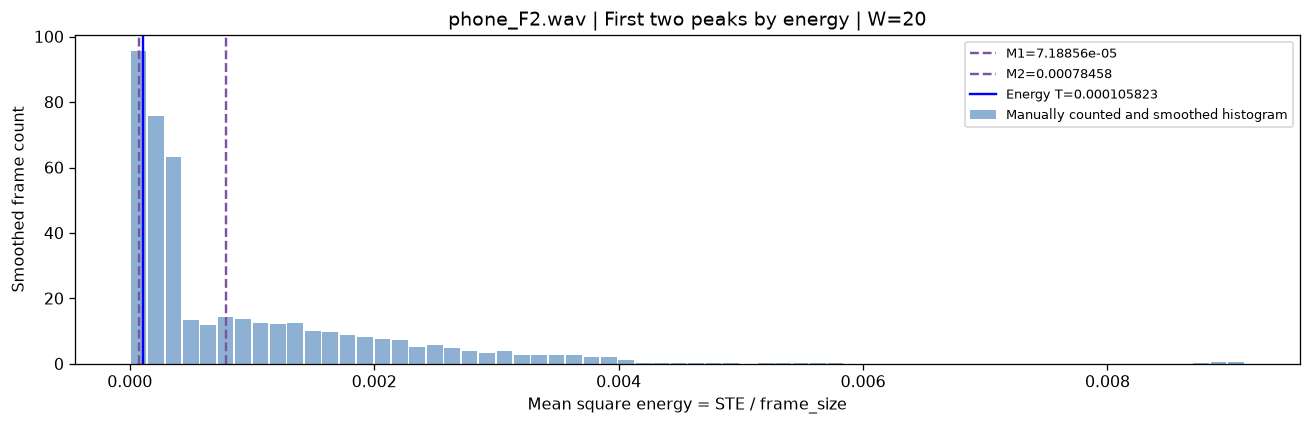

In [19]:
HISTOGRAM_TRAIN_ROWS = []
for record in TRAIN_RECORDS:
    threshold, details = threshold_from_histogram(record["features"]["energy"],
                                                  MODEL["bins"], MODEL["smooth_radius"], MODEL["W"])
    HISTOGRAM_TRAIN_ROWS.append(dict(file=record["name"], W=MODEL["W"],
                                     first_peak=details["first_peak"], second_peak=details["second_peak"],
                                     energy_threshold=threshold, fallback=details["fallback"]))
display_table(HISTOGRAM_TRAIN_ROWS,
              [("file", "TRAIN file"), ("W", "Final W"), ("first_peak", "M1"),
               ("second_peak", "M2"), ("energy_threshold", "Energy T"), ("fallback", "Fallback")],
              "First two peaks by increasing energy; T=(W*M1+M2)/(W+1)")

histogram_record = next(record for record in TEST_RECORDS if record["name"] == "phone_F2")
histogram_values = histogram_record["features"]["energy"]
centers, counts = histogram(histogram_values, MODEL["bins"], MODEL["smooth_radius"])
energy_threshold, histogram_details = threshold_from_histogram(
    histogram_values, MODEL["bins"], MODEL["smooth_radius"], MODEL["W"]
)
display_table([dict(file="phone_F2", W=MODEL["W"],
                    first_peak=histogram_details["first_peak"], second_peak=histogram_details["second_peak"],
                    energy_threshold=energy_threshold, fallback=histogram_details["fallback"])],
              [("file", "Illustration file"), ("W", "W"), ("first_peak", "M1"),
               ("second_peak", "M2"), ("energy_threshold", "Energy T"), ("fallback", "Fallback")],
              "Fresh phone_F2 energy histogram")
figure, axis = plt.subplots(figsize=(11.5, 3.8))
width = centers[1] - centers[0] if len(centers) > 1 else 1.0
axis.bar(centers, counts, width=width * 0.9, color="#729ec9", alpha=0.8,
         label="Manually counted and smoothed histogram")
for label, value in (("M1", histogram_details["first_peak"]), ("M2", histogram_details["second_peak"])):
    if value is not None:
        axis.axvline(value, color="#7854a1", linestyle="--", label=f"{label}={value:.6g}")
axis.axvline(energy_threshold, color="blue", linewidth=1.5, label=f"Energy T={energy_threshold:.6g}")
axis.set(xlabel="Mean square energy = STE / frame_size", ylabel="Smoothed frame count",
         title=f"phone_F2.wav | First two peaks by energy | W={MODEL['W']:g}")
axis.legend(fontsize=8)
figure.tight_layout()
plt.show()
plt.close(figure)


## Four TEST results

The main table scores the final confirmed regions. START/END columns are in seconds; MAE/RMSE are in milliseconds.


In [20]:
TEST_RESULTS_BY_MODE = {mode: [predict_and_score(ALGORITHM, record, model) for record in TEST_RECORDS]
                        for mode, model in MODELS.items()}
assert_model_locked()
ALL_RESULTS_BY_MODE = {mode: [predict_and_score(ALGORITHM, record, model) for record in ALL_RECORDS]
                       for mode, model in MODELS.items()}
assert_model_locked()
TEST_RESULTS, ALL_RESULTS = TEST_RESULTS_BY_MODE[MODE], ALL_RESULTS_BY_MODE[MODE]

def metric_rows(records, results):
    return [dict(file=record["name"], split=record["split"], algorithm=ALGORITHM,
                 **result["metrics"])
            for record, result in zip(records, results)]

TEST_METRICS_BY_MODE = {mode: metric_rows(TEST_RECORDS, results) for mode, results in TEST_RESULTS_BY_MODE.items()}
ALL_METRICS_BY_MODE = {mode: metric_rows(ALL_RECORDS, results) for mode, results in ALL_RESULTS_BY_MODE.items()}
TEST_SUMMARIES_BY_MODE = {mode: summarize(rows) for mode, rows in TEST_METRICS_BY_MODE.items()}
TEST_METRIC_ROWS = [row for rows in TEST_METRICS_BY_MODE.values() for row in rows]
ALL_METRIC_ROWS = [row for rows in ALL_METRICS_BY_MODE.values() for row in rows]
TEST_SUMMARY = TEST_SUMMARIES_BY_MODE[MODE]
METRIC_COLUMNS = [
    ("file", "File"), ("split", "Split"), ("endpoint_mode", "Mode"),
    ("ground_truth_region_count", "GT regions"), ("predicted_region_count", "Pred regions"),
    ("mae_ms", "Final MAE (ms)"), ("rmse_ms", "RMSE (ms)"), ("status", "Status"),
    ("start_error_ms", "Signed START error (ms)"), ("end_error_ms", "Signed END error (ms)"),
    ("gt_start_s", "GT START (s)"), ("gt_end_s", "GT END (s)"),
    ("predicted_start_s", "Pred START (s)"), ("predicted_end_s", "Pred END (s)")
]
display_table(TEST_METRIC_ROWS, METRIC_COLUMNS, "Four TEST recordings in each mode: FINAL-region endpoints")
THRESHOLD_ROWS = [dict(file=result["file"], endpoint_mode=mode,
                      **{key:result["diagnostic"].get(key) for key in
                         ("native_threshold", "native_threshold_units", "low_ste_threshold", "high_ste_threshold",
                          "geometry", "minimum_speech_ms", "padding_stage")})
                  for mode, results in ALL_RESULTS_BY_MODE.items() for result in results]
display_table(THRESHOLD_ROWS, [(key,key) for key in THRESHOLD_ROWS[0]], "Both-mode threshold and geometry diagnostics")


File,Split,Mode,GT regions,Pred regions,Final MAE (ms),RMSE (ms),Status,Signed START error (ms),Signed END error (ms),GT START (s),GT END (s),Pred START (s),Pred END (s)
phone_F2,test,core,1,2,N/A,N/A,extra predicted regions,N/A,N/A,1.02,4.04,1.05,4.015
phone_M2,test,core,1,1,2.5,3.53553391,OK,0,-5,0.53,2.52,0.53,2.515
studio_F2,test,core,1,1,17.5056689,19.0468767,OK,-10,-25.0113379,0.77,2.37,0.76,2.34498866
studio_M2,test,core,1,1,7.50566893,7.90928275,OK,10,-5.01133787,0.45,1.93,0.46,1.92498866
phone_F2,test,enhanced,1,1,32.5,39.5284708,boundary inside silence,-10,55,1.02,4.04,1.01,4.095
phone_M2,test,enhanced,1,1,7.5,7.90569415,OK,-10,5,0.53,2.52,0.52,2.525
studio_F2,test,enhanced,1,1,7.50566893,7.90928275,OK,-10,-5.01133787,0.77,2.37,0.76,2.36498866
studio_M2,test,enhanced,1,1,7.49433107,7.90211206,OK,10,4.98866213,0.45,1.93,0.46,1.93498866


file,endpoint_mode,native_threshold,native_threshold_units,low_ste_threshold,high_ste_threshold,geometry,minimum_speech_ms,padding_stage
phone_F1,core,0.0017156231,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
phone_M1,core,0.000178287733,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
studio_F1,core,0.000268489967,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
studio_M1,core,0.000271396706,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
phone_F2,core,0.000105823433,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
phone_M2,core,0.000206775886,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
studio_F2,core,0.00136423549,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
studio_M2,core,0.00025823544,sum of squared samples,N/A,N/A,union of active frame supports,0,excluded from core FINAL
phone_F1,enhanced,0.0017156231,sum of squared samples,0.00251496724,0.0133073323,union of active frame supports,100,candidate diagnostics only
phone_M1,enhanced,0.000178287733,sum of squared samples,0.00251496724,0.0126370153,union of active frame supports,100,candidate diagnostics only


### TEST summary

Mean, median, minimum, maximum, count correctness and highest-error files describe only the four TEST recordings.


In [21]:
display_table([row for rows in TEST_SUMMARIES_BY_MODE.values() for row in rows],
              [("algorithm", "Algorithm"), ("endpoint_mode", "Mode"), ("files", "Files"),
               ("evaluated_files", "Defined MAE files"), ("mean_file_mae_ms", "Mean MAE (ms)"),
               ("median_file_mae_ms", "Median (ms)"), ("min_file_mae_ms", "Min (ms)"),
               ("max_file_mae_ms", "Max (ms)"), ("mean_file_rmse_ms", "Mean file RMSE (ms)"),
               ("pooled_endpoint_rmse_ms", "Pooled endpoint RMSE (ms)"),
               ("region_count_correct_files", "Correct counts"),
               ("region_count_incorrect_files", "Incorrect counts"),
               ("mean_frame_f1", "Mean frame F1"), ("top_mae_files", "Highest MAE files"),
               ("evaluation_protocol", "Protocol")],
              "Summary of the four TEST recordings only")


Algorithm,Mode,Files,Defined MAE files,Mean MAE (ms),Median (ms),Min (ms),Max (ms),Mean file RMSE (ms),Pooled endpoint RMSE (ms),Correct counts,Incorrect counts,Mean frame F1,Highest MAE files,Protocol
tt2,core,4,3,N/A,7.50566893,2.5,17.5056689,N/A,N/A,3,1,0.980745514,studio_F2:17.51ms; studio_M2:7.51ms; phone_M2:2.50ms,train_selected_reused_test
tt2,enhanced,4,4,13.75,7.50283447,7.49433107,32.5,15.8113899,20.9165014,4,0,0.995463076,phone_F2:32.50ms; studio_F2:7.51ms; phone_M2:7.50ms,train_selected_reused_test


## All eight input files

This separate table includes TRAIN and TEST with explicit split labels. TRAIN results reuse the model fitted from TRAIN and therefore describe its training fit.


In [22]:
display_table(ALL_METRIC_ROWS, METRIC_COLUMNS, "All eight files: TRAIN and TEST shown explicitly")


File,Split,Mode,GT regions,Pred regions,Final MAE (ms),RMSE (ms),Status,Signed START error (ms),Signed END error (ms),GT START (s),GT END (s),Pred START (s),Pred END (s)
phone_F1,train,core,1,2,N/A,N/A,extra predicted regions,N/A,N/A,0.53,2.75,0.54,2.745
phone_M1,train,core,1,1,2.5,3.53553391,OK,0,5,0.46,3.52,0.46,3.525
studio_F1,train,core,1,1,7.50566893,7.90928275,OK,-10,-5.01133787,0.68,2.15,0.67,2.14498866
studio_M1,train,core,1,1,27.5056689,30.2104309,OK,40,-15.0113379,0.87,2.06,0.91,2.04498866
phone_F2,test,core,1,2,N/A,N/A,extra predicted regions,N/A,N/A,1.02,4.04,1.05,4.015
phone_M2,test,core,1,1,2.5,3.53553391,OK,0,-5,0.53,2.52,0.53,2.515
studio_F2,test,core,1,1,17.5056689,19.0468767,OK,-10,-25.0113379,0.77,2.37,0.76,2.34498866
studio_M2,test,core,1,1,7.50566893,7.90928275,OK,10,-5.01133787,0.45,1.93,0.46,1.92498866
phone_F1,train,enhanced,1,1,2.5,3.53553391,OK,0,-5,0.53,2.75,0.53,2.745
phone_M1,train,enhanced,1,1,12.5,17.6776695,OK,0,25,0.46,3.52,0.46,3.545


## Four inline TEST figures

Red indicates LAB ground truth, blue indicates final predicted regions. Waveform and normalized STE share the same time axis. Enhanced LOW/HIGH are actual confirmation thresholds; core plots native T and exports LOW/HIGH as null. Each recording has its own figure cell.


In [23]:
def plot_record(record, result):
    """Show waveform and normalized STE with only GT and FINAL boundaries."""
    features = record["features"]
    diagnostic = result["diagnostic"]
    mae = result["metrics"]["mae_ms"]
    mae_text = f"{mae:.2f} ms" if mae is not None else "N/A"
    figure, axes = plt.subplots(2, 1, figsize=(12.5, 5.5), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.25]})
    time = [index / record["sample_rate"] for index in range(len(record["samples"]))]
    axes[0].plot(time, record["samples"], color="#444444", linewidth=0.6)
    axes[0].set_ylabel("PCM amplitude")
    axes[1].plot(features["centers"], features["ste_norm"], color="#263238",
                 linewidth=1, label="Normalized STE")
    if diagnostic["endpoint_mode"] == "core":
        native = diagnostic["native_threshold"]
        if diagnostic["native_threshold_units"] == "sum of squared samples":
            peak = max(features["energy"], default=0.)
            native = native / peak if peak else 0.
        axes[1].axhline(native, color="#9b6700", linestyle=":", label="Native T (display normalized)")
    else:
        axes[1].axhline(diagnostic["low_ste_threshold"], color="#008060", linestyle="--", label="LOW")
        axes[1].axhline(diagnostic["high_ste_threshold"], color="#9b6700", linestyle=":", label="HIGH")
    for axis in axes:
        for index, (start, end) in enumerate(result["ground_truth_regions"]):
            axis.axvspan(start, end, color="red", alpha=0.05)
            axis.axvline(start, color="red", linestyle="--", linewidth=1.25,
                        label="GT boundary" if index == 0 else None)
            axis.axvline(end, color="red", linestyle="--", linewidth=1.25)
        for index, (start, end) in enumerate(result["final_regions"]):
            axis.axvspan(start, end, color="#1769d2", alpha=0.11)
            axis.axvline(start, color="#1769d2", linewidth=1.4,
                        label="FINAL predicted boundary" if index == 0 else None)
            axis.axvline(end, color="#1769d2", linewidth=1.4)
        axis.grid(alpha=0.16)
        axis.set_xlim(0, record["duration"])
    axes[1].set_ylabel("Normalized STE")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc="upper right", fontsize=8, ncol=3)
    figure.suptitle(f"{record['name']}.wav | {MODE} | FINAL-region endpoint MAE: {mae_text} | "
                   f"{len(result['final_regions'])} speech regions")
    figure.tight_layout()
    plt.show()
    plt.close(figure)


TEST_RECORDS_BY_FILE = {record["name"]: record for record in TEST_RECORDS}
TEST_RESULTS_BY_FILE = {result["file"]: result for result in TEST_RESULTS}


### phone_F2.wav


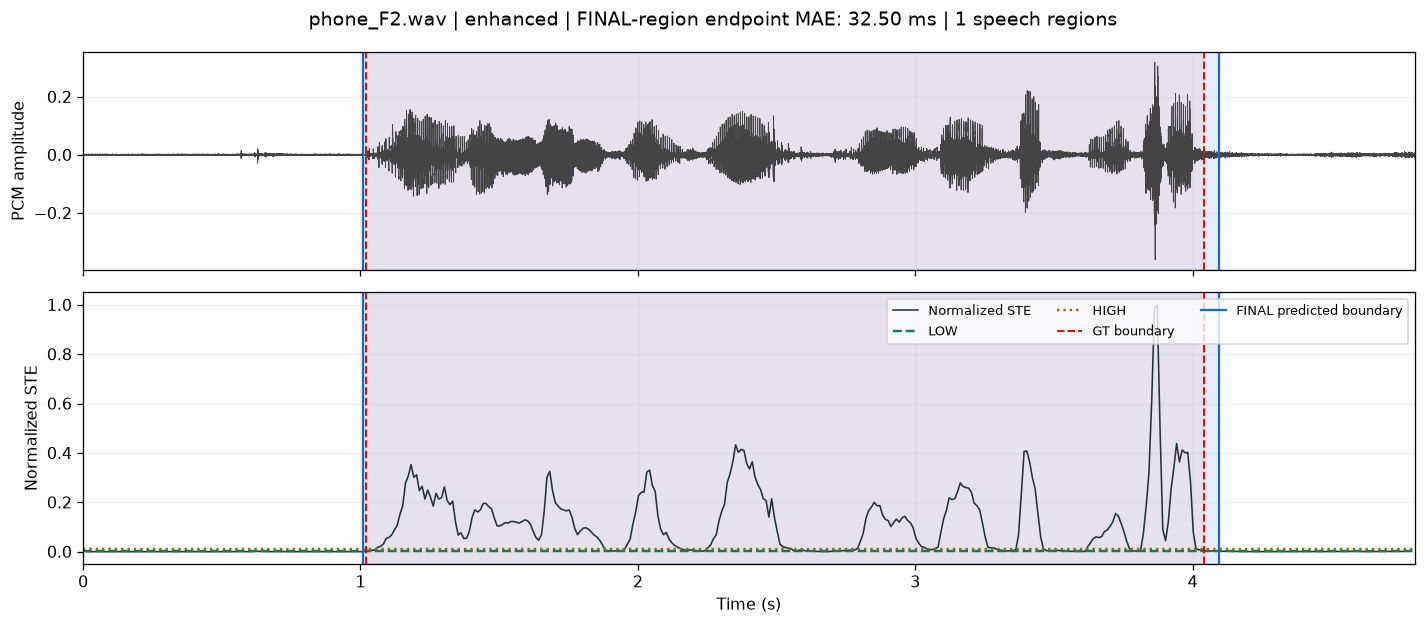

In [24]:
plot_record(TEST_RECORDS_BY_FILE["phone_F2"], TEST_RESULTS_BY_FILE["phone_F2"])


### phone_M2.wav


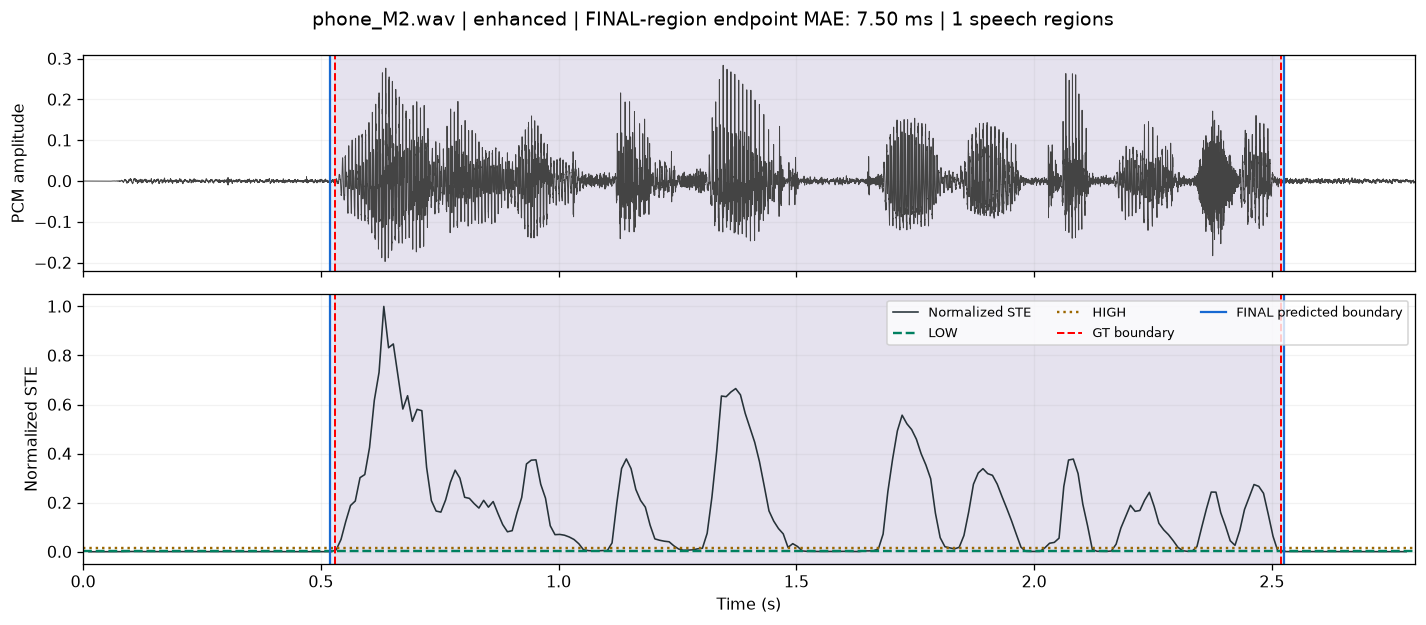

In [25]:
plot_record(TEST_RECORDS_BY_FILE["phone_M2"], TEST_RESULTS_BY_FILE["phone_M2"])


### studio_F2.wav


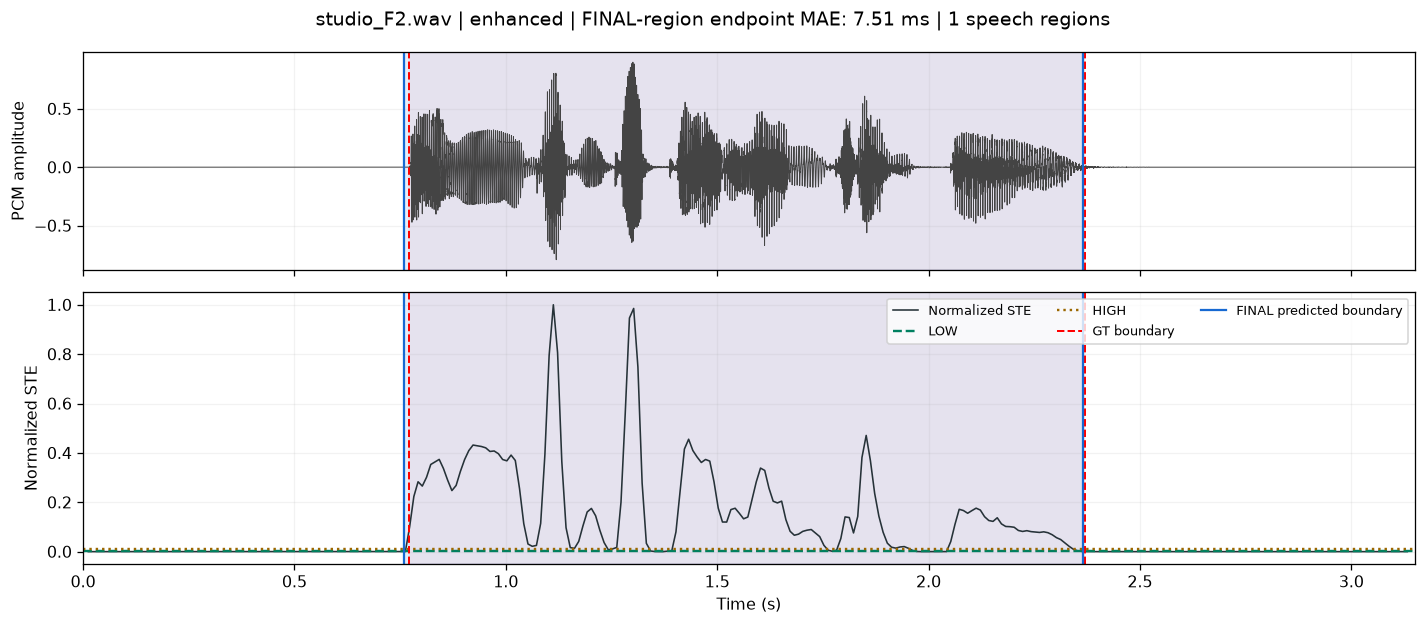

In [26]:
plot_record(TEST_RECORDS_BY_FILE["studio_F2"], TEST_RESULTS_BY_FILE["studio_F2"])


### studio_M2.wav


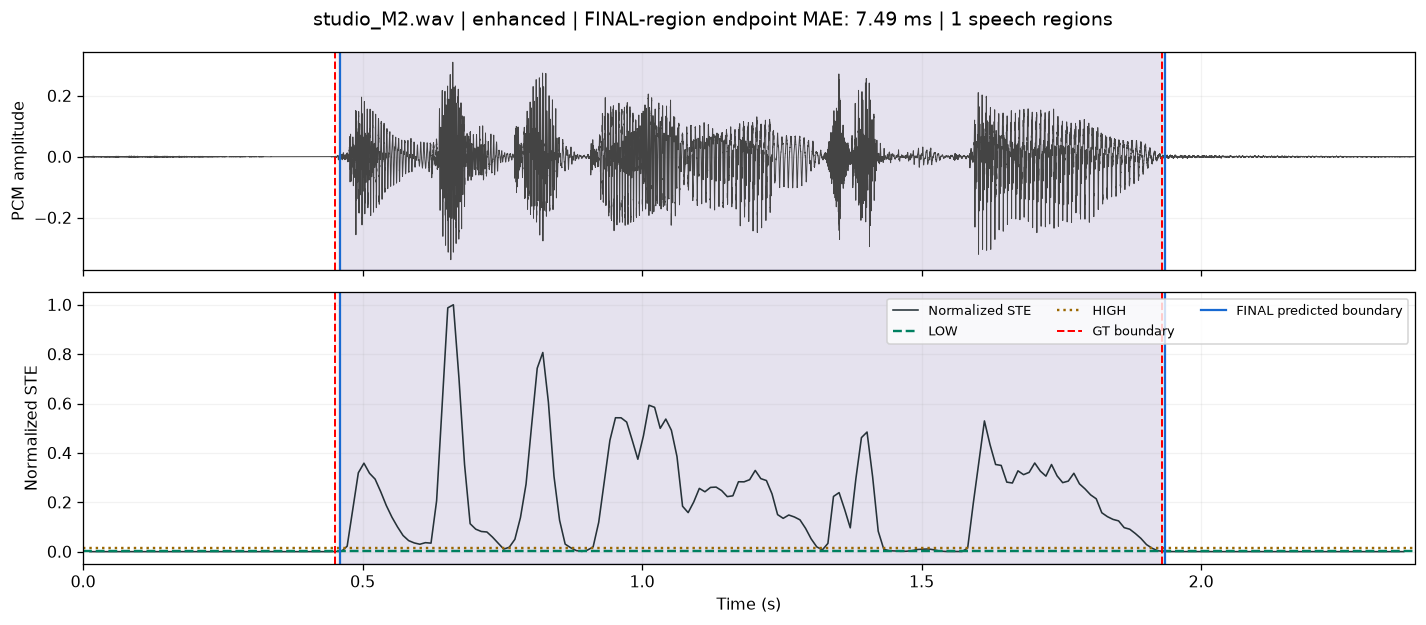

In [27]:
plot_record(TEST_RECORDS_BY_FILE["studio_M2"], TEST_RESULTS_BY_FILE["studio_M2"])


## Optional single-file demonstration

After running all previous cells, call `demo_one_file` with a dataset stem or WAV path. It uses the current model and performs no parameter tuning.


In [28]:
def demo_one_file(filename="phone_F2"):
    """Run one separately supplied WAV using the already fitted MODEL.

    Existing dataset files show LAB scores. An external WAV without a LAB is
    detected using the same fixed model; its reference score is undefined.
    This function never refits or tunes any model parameter.
    """
    requested = Path(filename)
    if not requested.suffix:
        requested = requested.with_suffix(".wav")
    if requested.suffix.lower() != ".wav":
        raise ValueError("Choose a .wav file or a dataset stem.")
    candidates = ([requested] if requested.is_absolute() else
                  [DATA_ROOT / "test" / requested, DATA_ROOT / "train" / requested,
                   Path.cwd() / requested])
    path = next((candidate for candidate in candidates if candidate.is_file()), None)
    if path is None:
        raise FileNotFoundError(f"WAV not found: {requested.name}")
    samples, fs = read_wav(path)
    duration = len(samples) / fs
    lab_path = path.with_suffix(".lab")
    intervals = read_lab(lab_path, duration) if lab_path.is_file() else []
    record = prepare_records([dict(name=path.stem, samples=samples, sample_rate=fs,
                                   duration=duration, intervals=intervals, split="demo")])[0]
    result = predict_and_score(ALGORITHM, record, MODEL)
    assert_model_locked()
    rows = metric_rows([record], [result])
    display_table(rows, METRIC_COLUMNS, "Single-file demonstration with fixed MODEL")
    plot_record(record, result)
    return result

# Uncomment to demonstrate a dataset file or provide a WAV path:
# demo_result = demo_one_file("phone_F2")
